<a href="https://colab.research.google.com/github/laharipallekala/bangalore-aqi-project/blob/main/03_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install prophet statsmodels scikit-learn scipy --quiet  # prophet is the updated package name (was fbprophet)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import statsmodels.api as sm  # OLS regression and diagnostics
from statsmodels.stats.outliers_influence import variance_inflation_factor  # VIF multicollinearity check
from statsmodels.stats.stattools import durbin_watson  # residual autocorrelation test
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # evaluation metrics
from sklearn.model_selection import TimeSeriesSplit  # time-aware cross-validation
from prophet import Prophet  # Facebook/Meta Prophet time-series model

plt.style.use('seaborn-v0_8-whitegrid')  # clean plot style
import os
os.makedirs('./processed', exist_ok=True)

# Load master CSV
master = pd.read_csv('./processed/bangalore_master_aqi.csv')  # load the cleaned dataset from Phase 1
master['Date'] = pd.to_datetime(master['Date'], format='%d-%m-%Y')  # parse date column with explicit format
master = master.sort_values('Date').reset_index(drop=True)

print('Master loaded:', master.shape)
print('Columns:', master.columns.tolist())
print('Date range:', master['Date'].min().date(), '->',
master['Date'].max().date())

Master loaded: (2009, 12)
Columns: ['Date', 'year', 'month', 'season', 'day_of_week', 'AQI', 'PM2.5', 'PM10', 'temp', 'humidity', 'wind_speed', 'rainfall']
Date range: 2015-01-01 -> 2020-07-01


In [2]:
##feature engineering for modeling

In [3]:
#lag variables
master['AQI_lag1']   = master['AQI'].shift(1)  # shift(1) = value from 1 day ago
master['AQI_lag7']   = master['AQI'].shift(7)  # value from 7 days ago (same day last week)
master['PM25_lag1']  = master['PM2.5'].shift(1)  # yesterday's PM2.5
master['AQI_roll7']  = master['AQI'].rolling(7).mean()  # 7-day rolling average — captures recent trend
master['AQI_roll30'] = master['AQI'].rolling(30).mean()  # 30-day rolling average — captures seasonal trend

master = master.dropna()  # drop first 30 rows where rolling averages are NaN
master = master.reset_index(drop=True)

print('Shape after lag features:', master.shape)
print('New lag columns:',
['AQI_lag1','AQI_lag7','PM25_lag1','AQI_roll7','AQI_roll30'])
print(master[['Date','AQI','AQI_lag1','AQI_lag7','AQI_roll7']].head(5))

Shape after lag features: (1980, 17)
New lag columns: ['AQI_lag1', 'AQI_lag7', 'PM25_lag1', 'AQI_roll7', 'AQI_roll30']
        Date         AQI    AQI_lag1    AQI_lag7   AQI_roll7
0 2015-01-30  111.729032  111.729032  111.729032  111.729032
1 2015-01-31  111.729032  111.729032  111.729032  111.729032
2 2015-02-01  109.514085  111.729032  111.729032  111.412611
3 2015-02-02  109.514085  109.514085  111.729032  111.096190
4 2015-02-03  109.514085  109.514085  111.729032  110.779769


In [4]:
#one hot encode categorical features
season_dummies  = pd.get_dummies(master['season'],      prefix='season',
drop_first=True)  # drop_first avoids perfect multicollinearity (dummy variable trap)
dow_dummies     = pd.get_dummies(master['day_of_week'], prefix='dow',
drop_first=True)  # day of week dummies

master_encoded = pd.concat([master, season_dummies, dow_dummies], axis=1)  # add new columns to the right of the dataframe

print('Encoded shape:', master_encoded.shape)
print('Season dummy columns:', [c for c in master_encoded.columns if c.startswith('season_')])
print('Day dummy columns:', [c for c in master_encoded.columns if c.startswith('dow_')])
print(master_encoded[['season'] + [c for  c in master_encoded.columns if c.startswith('season_')]].head(8))

Encoded shape: (1980, 26)
Season dummy columns: ['season_Post-Monsoon', 'season_Summer', 'season_Winter']
Day dummy columns: ['dow_Monday', 'dow_Saturday', 'dow_Sunday', 'dow_Thursday', 'dow_Tuesday', 'dow_Wednesday']
   season  season_Post-Monsoon  season_Summer  season_Winter
0  Winter                False          False           True
1  Winter                False          False           True
2  Winter                False          False           True
3  Winter                False          False           True
4  Winter                False          False           True
5  Winter                False          False           True
6  Winter                False          False           True
7  Winter                False          False           True


In [5]:
# VIF multicollinearity check — remove problematic features
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Define the initial feature set for VIF check
feature_cols = [
    'temp', 'humidity', 'wind_speed', 'rainfall',
    'AQI_lag1', 'AQI_lag7', 'PM25_lag1', 'AQI_roll7', ] + [c for c in master_encoded.columns if c.startswith('season_')] + [c for c in master_encoded.columns if c.startswith('dow_')]

X_vif = master_encoded[feature_cols].dropna()  # only numeric, no NaN

# Convert boolean columns (from one-hot encoding) to integers (0 or 1)
boolean_cols = [col for col in X_vif.columns if X_vif[col].dtype == 'bool']
for col in boolean_cols:
    X_vif[col] = X_vif[col].astype(int)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]  # compute VIF for each column
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

print('=== VIF Results ===')
print(vif_data.to_string())
print('\nFeatures with VIF > 10 (HIGH multicollinearity):')
print(vif_data[vif_data['VIF'] > 10]['Feature'].tolist())
print('\nFeatures with VIF > 5 (MODERATE multicollinearity):')
print(vif_data[vif_data['VIF'] > 5]['Feature'].tolist())

=== VIF Results ===
                Feature        VIF
0                  temp  75.228037
1              humidity  35.847133
2             AQI_roll7  35.029273
3              AQI_lag1  16.567683
4            wind_speed  14.924528
5              AQI_lag7  10.090520
6             PM25_lag1   5.282253
7         season_Summer   4.540362
8         season_Winter   2.463775
9            dow_Monday   1.995417
10           dow_Sunday   1.992161
11         dow_Saturday   1.991799
12        dow_Wednesday   1.990090
13         dow_Thursday   1.989028
14          dow_Tuesday   1.987029
15  season_Post-Monsoon   1.762307
16             rainfall   1.634424

Features with VIF > 10 (HIGH multicollinearity):
['temp', 'humidity', 'AQI_roll7', 'AQI_lag1', 'wind_speed', 'AQI_lag7']

Features with VIF > 5 (MODERATE multicollinearity):
['temp', 'humidity', 'AQI_roll7', 'AQI_lag1', 'wind_speed', 'AQI_lag7', 'PM25_lag1']


In [6]:
#vif removal
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

def compute_vif(df, features):
    X = df[features].dropna()
    # Convert boolean columns (from one-hot encoding) to integers (0 or 1)
    boolean_cols = [col for col in X.columns if X[col].dtype == 'bool']
    for col in boolean_cols:
        X[col] = X[col].astype(int)
    vif = pd.DataFrame()
    vif['Feature'] = features
    vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(features))]
    return vif.sort_values('VIF', ascending=False).reset_index(drop=True)

# Start with original feature set
current_features = [
    'temp', 'humidity', 'wind_speed', 'rainfall',
    'AQI_lag1', 'AQI_lag7', 'PM25_lag1', 'AQI_roll7',] + [c for c in master_encoded.columns if c.startswith('season_')] + [c for c in master_encoded.columns if c.startswith('dow_')]

# ── Round 1: Remove temp (VIF 75) ─────────────────────────────────
current_features.remove('temp')
print('=== Round 1: After removing temp ===')
print(compute_vif(master_encoded, current_features).to_string())
print()

=== Round 1: After removing temp ===
                Feature        VIF
0             AQI_roll7  33.347698
1              humidity  20.257105
2              AQI_lag1  16.567392
3            wind_speed  12.091591
4              AQI_lag7  10.054188
5             PM25_lag1   5.163876
6         season_Winter   2.413994
7         season_Summer   2.248768
8         dow_Wednesday   1.944691
9          dow_Saturday   1.942253
10         dow_Thursday   1.941915
11          dow_Tuesday   1.938002
12           dow_Monday   1.937949
13           dow_Sunday   1.937747
14  season_Post-Monsoon   1.723130
15             rainfall   1.570549



In [7]:
# ── Round 2: Remove AQI_roll7 (redundant with lags) ───────────────
current_features.remove('AQI_roll7')
print('=== Round 2: After removing AQI_roll7 ===')
print(compute_vif(master_encoded, current_features).to_string())
print()

=== Round 2: After removing AQI_roll7 ===
                Feature        VIF
0              humidity  19.727902
1            wind_speed  12.072362
2              AQI_lag1   8.453659
3              AQI_lag7   7.459523
4             PM25_lag1   5.147187
5         season_Winter   2.330328
6         season_Summer   2.169088
7         dow_Wednesday   1.943568
8          dow_Saturday   1.941434
9          dow_Thursday   1.939034
10           dow_Sunday   1.937121
11          dow_Tuesday   1.935095
12           dow_Monday   1.935015
13  season_Post-Monsoon   1.706751
14             rainfall   1.569171



In [8]:
# ── Round 3: Remove humidity (proxied by season dummies) ──────────
current_features.remove('humidity')
print('=== Round 3: After removing humidity ===')
print(compute_vif(master_encoded, current_features).to_string())
print()

=== Round 3: After removing humidity ===
                Feature       VIF
0              AQI_lag1  8.282618
1              AQI_lag7  7.206796
2            wind_speed  6.197476
3             PM25_lag1  5.137235
4         season_Winter  2.328293
5         season_Summer  2.159515
6            dow_Monday  1.853541
7          dow_Saturday  1.845188
8            dow_Sunday  1.844281
9         dow_Wednesday  1.842543
10         dow_Thursday  1.839063
11          dow_Tuesday  1.834460
12  season_Post-Monsoon  1.604133
13             rainfall  1.255722



In [9]:
# ── Round 4: Remove AQI_lag7 (keep AQI_lag1 only) ─────────────────
current_features.remove('AQI_lag7')
print('=== Round 4: After removing AQI_lag7 ===')
print(compute_vif(master_encoded, current_features).to_string())
print()

=== Round 4: After removing AQI_lag7 ===
                Feature       VIF
0              AQI_lag1  7.083544
1            wind_speed  5.684378
2             PM25_lag1  5.137167
3         season_Winter  2.183853
4         season_Summer  2.014876
5            dow_Monday  1.846532
6            dow_Sunday  1.834665
7         dow_Wednesday  1.832860
8          dow_Thursday  1.832022
9          dow_Saturday  1.831369
10          dow_Tuesday  1.820739
11  season_Post-Monsoon  1.550232
12             rainfall  1.252292



In [10]:
# ── Final check: all should be below 10 ───────────────────────────
final_vif = compute_vif(master_encoded, current_features)
print('=== FINAL VIF CHECK ===')
print(final_vif.to_string())
print()

high = final_vif[final_vif['VIF'] > 10]
if len(high) == 0:
    print('PASS — all features have VIF < 10')
    print('Final feature set:', current_features)
else:
    print('Still high VIF:', high['Feature'].tolist())
    print('Remove these and re-run')

# Save final feature set
final_features = current_features

=== FINAL VIF CHECK ===
                Feature       VIF
0              AQI_lag1  7.083544
1            wind_speed  5.684378
2             PM25_lag1  5.137167
3         season_Winter  2.183853
4         season_Summer  2.014876
5            dow_Monday  1.846532
6            dow_Sunday  1.834665
7         dow_Wednesday  1.832860
8          dow_Thursday  1.832022
9          dow_Saturday  1.831369
10          dow_Tuesday  1.820739
11  season_Post-Monsoon  1.550232
12             rainfall  1.252292

PASS — all features have VIF < 10
Final feature set: ['wind_speed', 'rainfall', 'AQI_lag1', 'PM25_lag1', 'season_Post-Monsoon', 'season_Summer', 'season_Winter', 'dow_Monday', 'dow_Saturday', 'dow_Sunday', 'dow_Thursday', 'dow_Tuesday', 'dow_Wednesday']


In [11]:
## Chronological Train/Test Split
# Define target and features
TARGET = 'AQI'
FEATURES = final_features

df_model = master_encoded[['Date', TARGET] +
FEATURES].dropna().reset_index(drop=True)  # clean working dataframe

# Chronological split — NO shuffling
split_idx = int(len(df_model) * 0.80)  # index of the 80% mark

train_df = df_model.iloc[:split_idx]  # first 80% of dates = training set
test_df  = df_model.iloc[split_idx:]  # last 20% of dates = test set

print(f'Training set: {len(train_df)} rows ({train_df["Date"].min().date()} to {train_df["Date"].max().date()})')
print(f'Test set:     {len(test_df)} rows ({test_df["Date"].min().date()} to {test_df["Date"].max().date()})')
print(f'Train size: {len(train_df)/len(df_model)*100:.1f}%  |  Test size: {len(test_df)/len(df_model)*100:.1f}%')

X_train = train_df[FEATURES]  # training features
y_train = train_df[TARGET]  # training target (AQI)
X_test  = test_df[FEATURES]  # test features
y_test  = test_df[TARGET]  # test target (AQI)

Training set: 1584 rows (2015-01-30 to 2019-06-01)
Test set:     396 rows (2019-06-02 to 2020-07-01)
Train size: 80.0%  |  Test size: 20.0%


In [12]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)  # 5 time-aware folds

print('TimeSeriesSplit fold sizes:')
for i, (train_idx, test_idx) in enumerate(tscv.split(df_model)):
    fold_train = df_model.iloc[train_idx]
    fold_test  = df_model.iloc[test_idx]
    print(f'  Fold {i+1}: Train {fold_train["Date"].min().date()} to {fold_train["Date"].max().date()} | Test {fold_test["Date"].min().date()} to {fold_test["Date"].max().date()}')

TimeSeriesSplit fold sizes:
  Fold 1: Train 2015-01-30 to 2015-12-25 | Test 2015-12-26 to 2016-11-19
  Fold 2: Train 2015-01-30 to 2016-11-19 | Test 2016-11-20 to 2017-10-15
  Fold 3: Train 2015-01-30 to 2017-10-15 | Test 2017-10-16 to 2018-09-10
  Fold 4: Train 2015-01-30 to 2018-09-10 | Test 2018-09-11 to 2019-08-06
  Fold 5: Train 2015-01-30 to 2019-08-06 | Test 2019-08-07 to 2020-07-01


In [13]:
##linear Regression with OLS diagnostics
import statsmodels.api as sm

# Convert boolean columns to integers (0 or 1) in X_train and X_test
for col in X_train.select_dtypes(include='bool').columns:
    X_train[col] = X_train[col].astype(int)
for col in X_test.select_dtypes(include='bool').columns:
    X_test[col] = X_test[col].astype(int)

X_train_const = sm.add_constant(X_train)  # add intercept column — statsmodels requires this explicitly
X_test_const  = sm.add_constant(X_test, has_constant='add')  # same for test set

ols_model = sm.OLS(y_train, X_train_const).fit()  # fit OLS regression on training data

print(ols_model.summary())  # print full statistical summary

                            OLS Regression Results                            
Dep. Variable:                    AQI   R-squared:                       0.434
Model:                            OLS   Adj. R-squared:                  0.430
Method:                 Least Squares   F-statistic:                     92.73
Date:                Wed, 03 Jun 2026   Prob (F-statistic):          1.72e-183
Time:                        12:49:40   Log-Likelihood:                -7746.1
No. Observations:                1584   AIC:                         1.552e+04
Df Residuals:                    1570   BIC:                         1.560e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  40.0180    

In [14]:
#generate predictions and compute evaluation metrics
# Predictions on test set
y_pred_ols = ols_model.predict(X_test_const)  # apply model to test set features

# Evaluation metrics
mae_ols  = mean_absolute_error(y_test, y_pred_ols)  # Mean Absolute Error — average prediction error in AQI units
rmse_ols = np.sqrt(mean_squared_error(y_test, y_pred_ols))  # Root Mean Squared Error penalises large errors more than MAE
r2_ols   = r2_score(y_test, y_pred_ols)  # R² on test set — what % of variance is explained

print('=== OLS Linear Regression — Test Set Performance ===')
print(f'MAE:  {mae_ols:.2f} AQI units')
print(f'RMSE: {rmse_ols:.2f} AQI units')
print(f'R²:   {r2_ols:.4f}')

# Durbin-Watson test on training residuals
dw_stat = durbin_watson(ols_model.resid)  # test for autocorrelation in residuals
print(f'\nDurbin-Watson statistic: {dw_stat:.4f}')
if dw_stat < 1.5:
    print('Interpretation: DW < 1.5 → Positive autocorrelation in residuals (common in time series)')
elif dw_stat > 2.5:
    print('Interpretation: DW > 2.5 → Negative autocorrelation in residuals')
else:
    print('Interpretation: DW near 2 → No significant autocorrelation')

=== OLS Linear Regression — Test Set Performance ===
MAE:  9.35 AQI units
RMSE: 12.00 AQI units
R²:   0.6239

Durbin-Watson statistic: 2.0800
Interpretation: DW near 2 → No significant autocorrelation


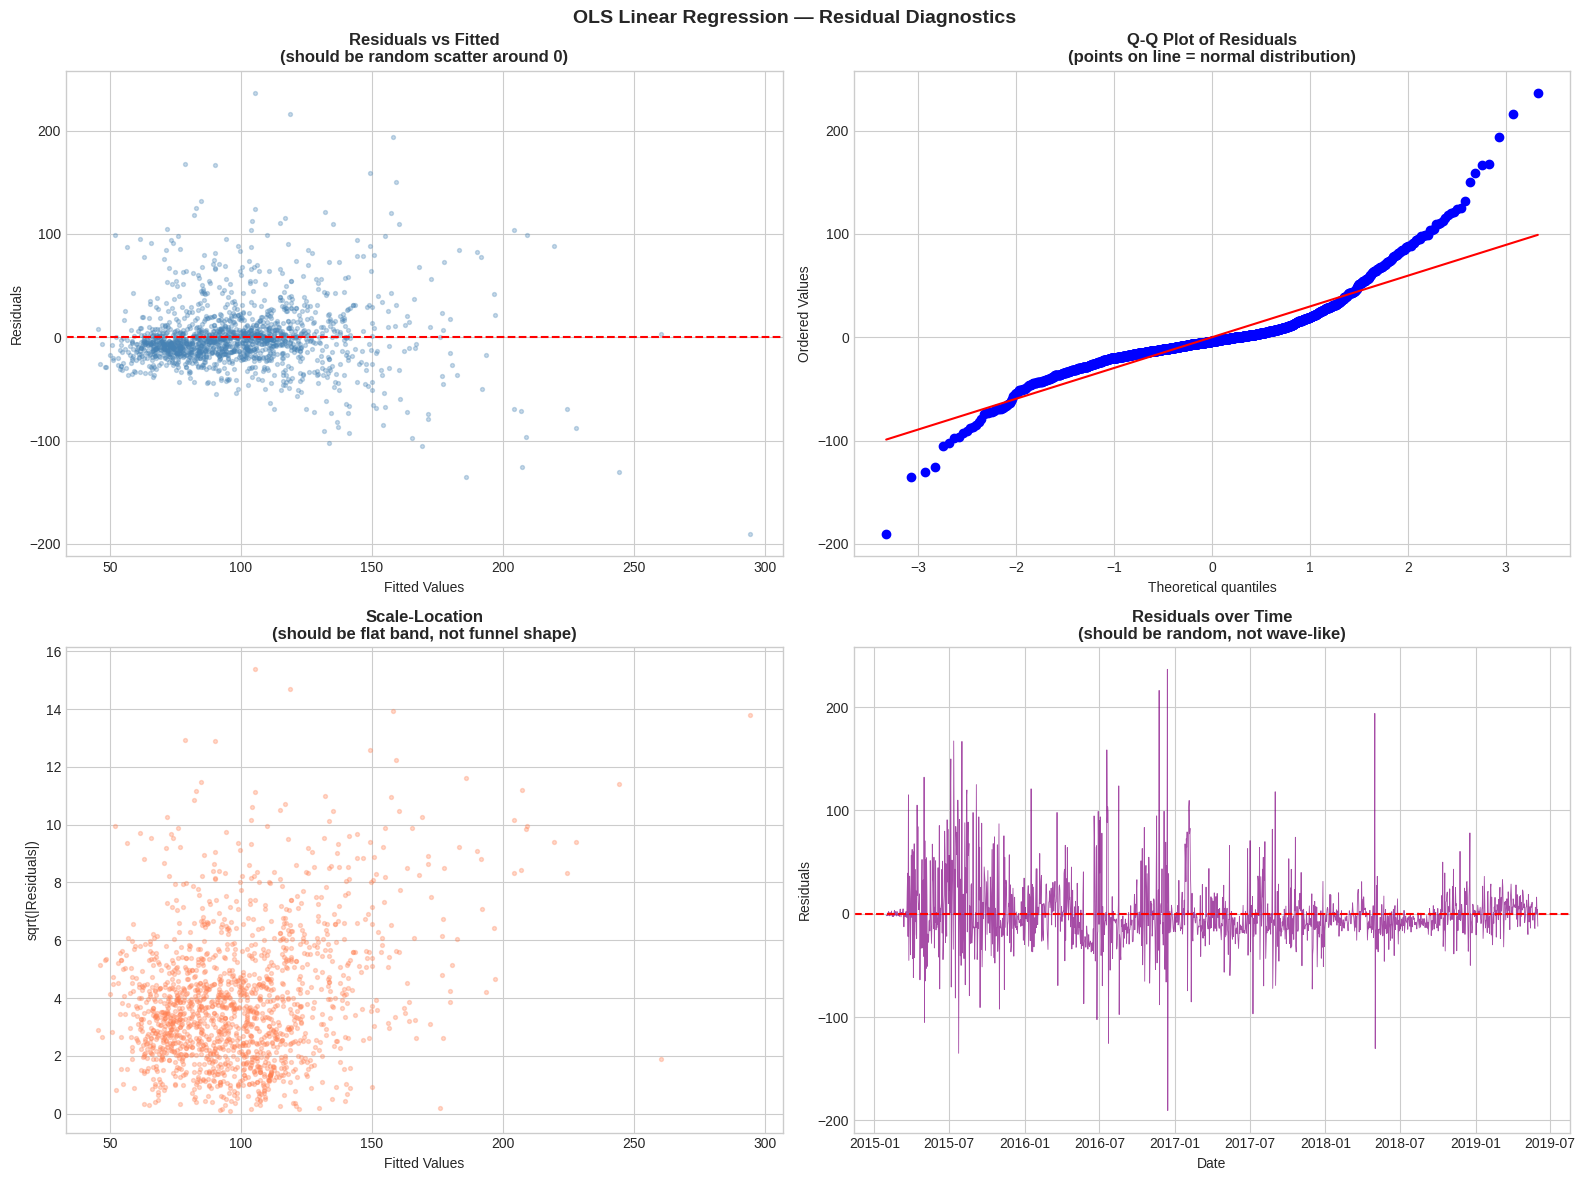

In [15]:
##residual diagnostic plots
residuals    = ols_model.resid
fitted_vals  = ols_model.fittedvalues

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig)

# Plot 1: Residuals vs Fitted (checks linearity and homoscedasticity)
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(fitted_vals, residuals, alpha=0.3, s=8, color='steelblue')  # each dot = one observation
ax1.axhline(y=0, color='red', linestyle='--', linewidth=1.5)  # red line at zero = what we want residuals to be near
ax1.set_xlabel('Fitted Values')
ax1.set_ylabel('Residuals')
ax1.set_title('Residuals vs Fitted\n(should be random scatter around 0)',
fontweight='bold')

# Plot 2: Q-Q Plot (checks normality of residuals)
ax2 = fig.add_subplot(gs[0, 1])
from scipy.stats import probplot
probplot(residuals, plot=ax2)
ax2.set_title('Q-Q Plot of Residuals\n(points on line = normal distribution)',
fontweight='bold')

# Plot 3: Scale-Location (checks homoscedasticity)
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(fitted_vals, np.sqrt(np.abs(residuals)), alpha=0.3, s=8, color='coral')  # sqrt of absolute residuals
ax3.set_xlabel('Fitted Values')
ax3.set_ylabel('sqrt(|Residuals|)')
ax3.set_title('Scale-Location\n(should be flat band, not funnel shape)', fontweight='bold')

# Plot 4: Residuals over time (checks temporal autocorrelation)
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(train_df['Date'], residuals.values, color='purple', linewidth=0.6, alpha=0.7)  # residuals plotted in time order
ax4.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
ax4.set_xlabel('Date')
ax4.set_ylabel('Residuals')
ax4.set_title('Residuals over Time\n(should be random, not wave-like)',
fontweight='bold')

plt.suptitle('OLS Linear Regression — Residual Diagnostics', fontsize=14,
fontweight='bold')
plt.tight_layout()
plt.savefig('./processed/plot_ols_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

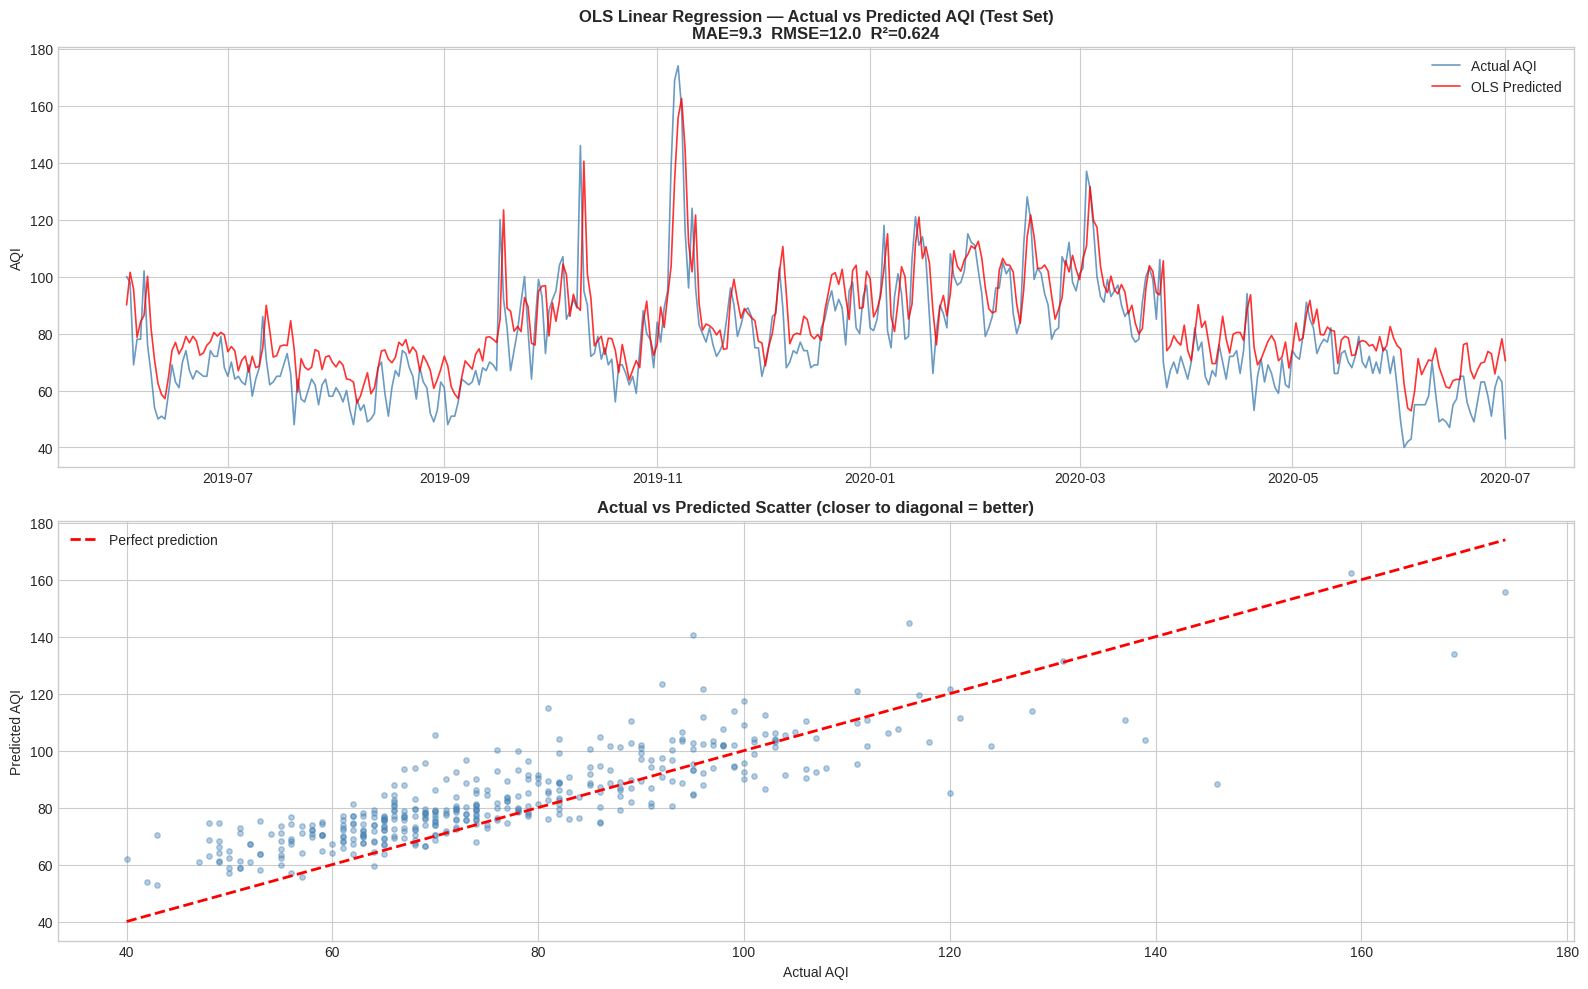

In [16]:
##actual vs predicted plot for ols
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Time series: actual vs predicted
axes[0].plot(test_df['Date'], y_test.values,   color='steelblue', linewidth=1.2, label='Actual AQI',    alpha=0.8)
axes[0].plot(test_df['Date'], y_pred_ols,      color='red',       linewidth=1.2, label='OLS Predicted', alpha=0.8)
axes[0].set_title(f'OLS Linear Regression — Actual vs Predicted AQI (Test Set)\nMAE={mae_ols:.1f}  RMSE={rmse_ols:.1f}  R²={r2_ols:.3f}', fontweight='bold')
axes[0].set_ylabel('AQI')
axes[0].legend()

# Scatter: actual vs predicted (perfect model = points on diagonal)
axes[1].scatter(y_test, y_pred_ols, alpha=0.4, s=15, color='steelblue')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect prediction')  # 45-degree line = perfect model
axes[1].set_xlabel('Actual AQI')
axes[1].set_ylabel('Predicted AQI')
axes[1].set_title('Actual vs Predicted Scatter (closer to diagonal = better)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('./processed/plot_ols_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
##prophet time series model

In [18]:
#preparing data in prophet form
# Prophet requires columns named exactly 'ds' and 'y'
prophet_df = master[['Date', 'AQI']].rename(columns={'Date': 'ds', 'AQI': 'y'})  # rename to Prophet's required format
prophet_df = prophet_df.dropna().reset_index(drop=True)

# Same chronological split as before
split_idx_p = int(len(prophet_df) * 0.80)
train_prophet = prophet_df.iloc[:split_idx_p]  # first 80% for training
test_prophet  = prophet_df.iloc[split_idx_p:]  # last 20% for evaluation

print('Prophet train set:', len(train_prophet), 'rows')
print('Prophet test set:', len(test_prophet), 'rows')
print('Train date range:', train_prophet['ds'].min().date(), '->', train_prophet['ds'].max().date())
print('Test date range:', test_prophet['ds'].min().date(), '->', test_prophet['ds'].max().date())
print(train_prophet.head())

Prophet train set: 1584 rows
Prophet test set: 396 rows
Train date range: 2015-01-30 -> 2019-06-01
Test date range: 2019-06-02 -> 2020-07-01
          ds           y
0 2015-01-30  111.729032
1 2015-01-31  111.729032
2 2015-02-01  109.514085
3 2015-02-02  109.514085
4 2015-02-03  109.514085


In [19]:
#fit basic prophet model
from prophet import Prophet

model_prophet = Prophet(
    yearly_seasonality=True,  # captures annual AQI cycle — critical for this dataset
    weekly_seasonality=True,  # captures weekday patterns
    daily_seasonality=False,  # we have daily data so this doesn't apply
    seasonality_mode='additive',  # additive: seasonal effect is constant in size
    changepoint_prior_scale=0.05  # controls how flexible the trend is (0.05 = moderate flexibility)
    )

model_prophet.fit(train_prophet)  # fit on training data only — never include test data here
print('Prophet model fitted successfully.')

Prophet model fitted successfully.


In [20]:
#generate forecast and evaluate on test set
# Create future dataframe — must include both train AND test dates for evaluation
future = model_prophet.make_future_dataframe(periods=len(test_prophet), freq='D')
# extend the dataframe by the number of test days

forecast = model_prophet.predict(future)  # generate predictions for all dates including future

# Extract predictions for the test period only
forecast_test = forecast.tail(len(test_prophet))  # last N rows correspond to test period

# Evaluation metrics
y_pred_prophet = forecast_test['yhat'].values
y_actual       = test_prophet['y'].values

mae_prophet  = mean_absolute_error(y_actual, y_pred_prophet)
rmse_prophet = np.sqrt(mean_squared_error(y_actual, y_pred_prophet))
r2_prophet   = r2_score(y_actual, y_pred_prophet)

print('=== Prophet — Test Set Performance ===')
print(f'MAE:  {mae_prophet:.2f} AQI units')
print(f'RMSE: {rmse_prophet:.2f} AQI units')
print(f'R²:   {r2_prophet:.4f}')

=== Prophet — Test Set Performance ===
MAE:  53.03 AQI units
RMSE: 56.67 AQI units
R²:   -7.3886


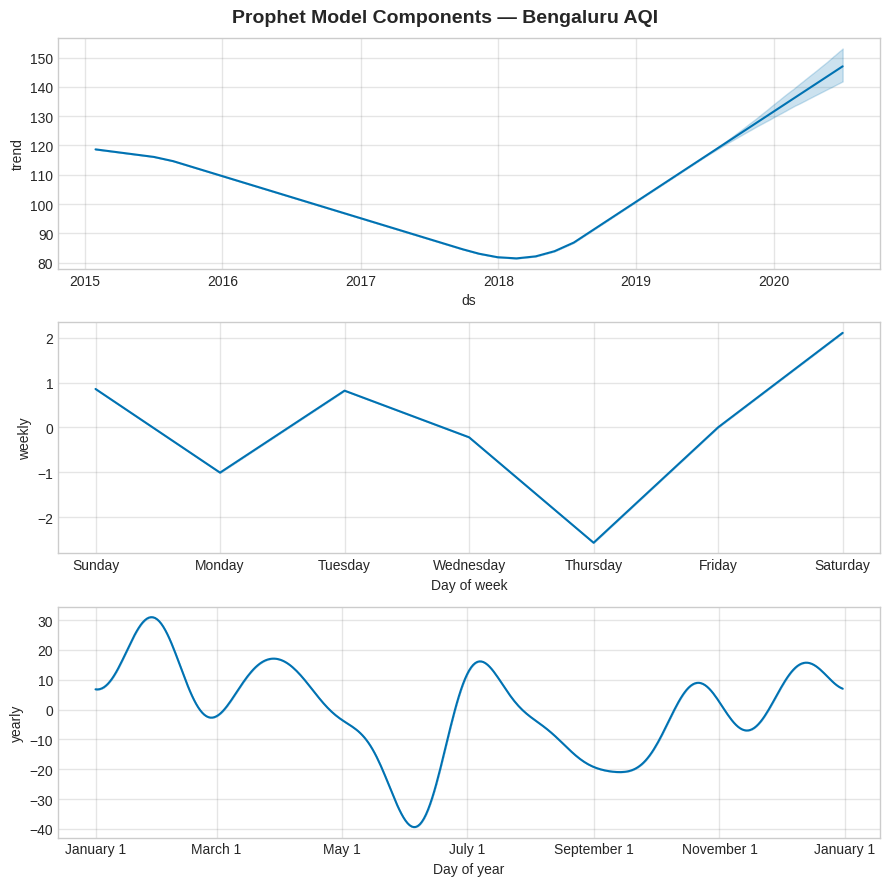

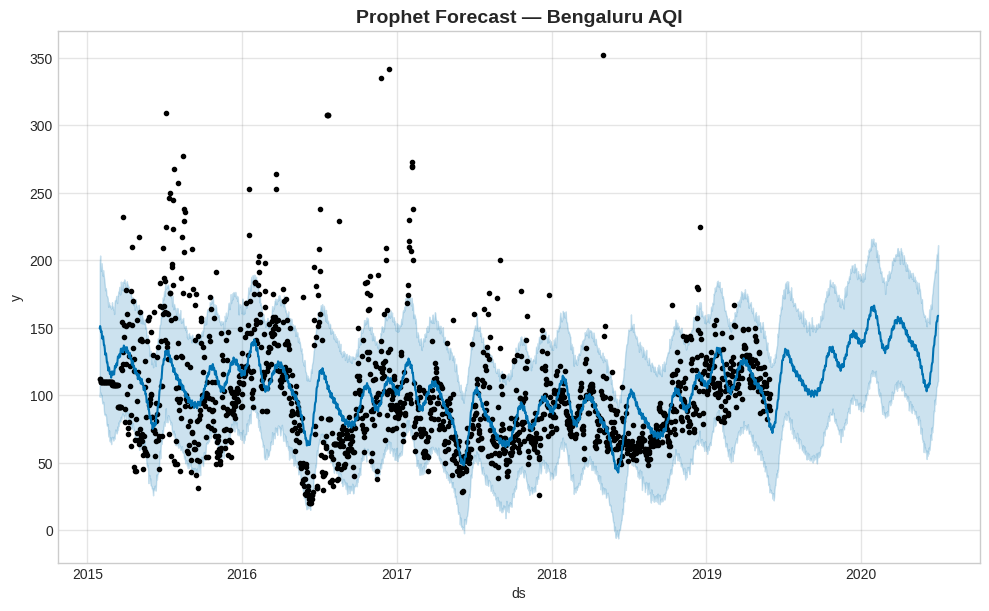

In [21]:
#plot Prophet forecast components
# Component plots — shows trend, yearly, and weekly seasonality separately
fig_components = model_prophet.plot_components(forecast)  # built-in Prophet plotting function
fig_components.suptitle('Prophet Model Components — Bengaluru AQI', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./processed/plot_prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()

# Full forecast plot with uncertainty intervals
fig_forecast = model_prophet.plot(forecast)  # shows prediction with confidence band
plt.title('Prophet Forecast — Bengaluru AQI', fontsize=14, fontweight='bold')
plt.savefig('./processed/plot_prophet_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

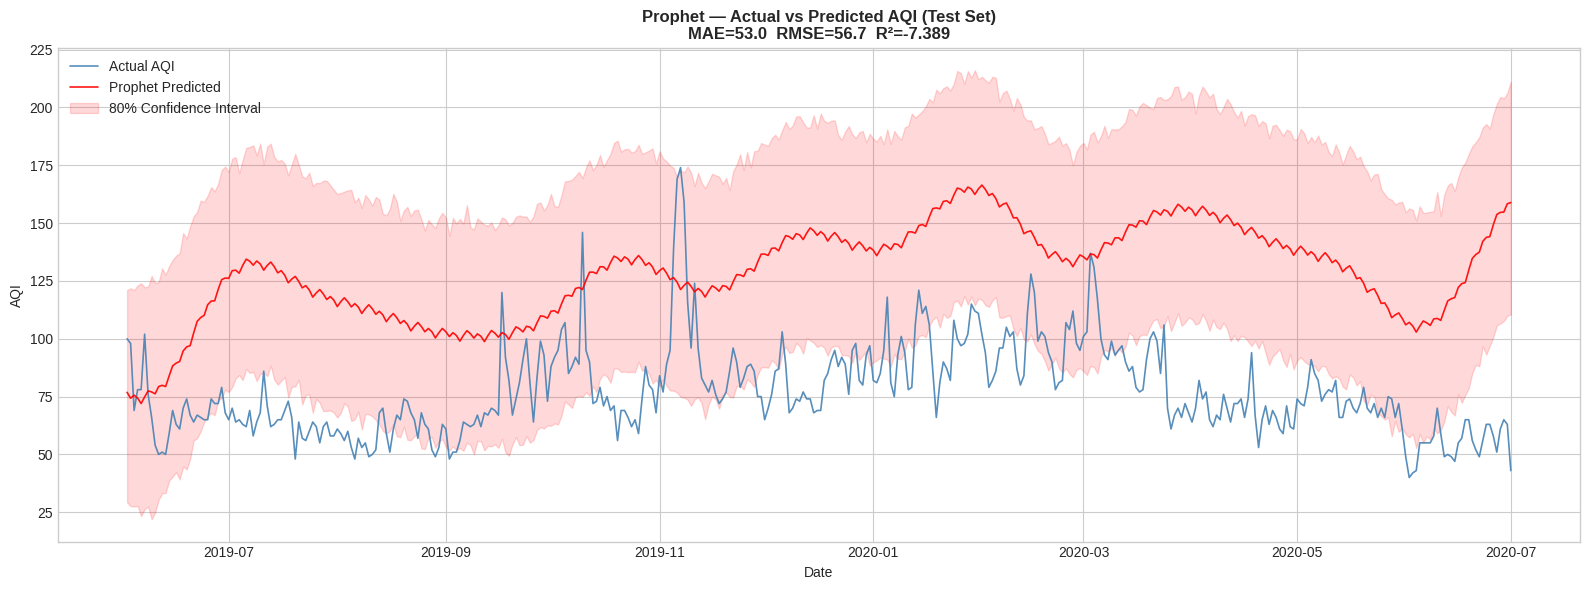

In [22]:
#Actual vs Predicted comparison for Prophet
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(test_prophet['ds'], y_actual, color='steelblue', linewidth=1.2, label='Actual AQI',alpha=0.9)
ax.plot(forecast_test['ds'], y_pred_prophet,color='red', linewidth=1.2, label='Prophet Predicted',alpha=0.9)
ax.fill_between(forecast_test['ds'],
                forecast_test['yhat_lower'],  # lower 80% confidence bound
                forecast_test['yhat_upper'],  # upper 80% confidence bound
                alpha=0.15, color='red', label='80% Confidence Interval')

ax.set_title(f'Prophet — Actual vs Predicted AQI (Test Set)\nMAE={mae_prophet:.1f}  RMSE={rmse_prophet:.1f}  R²={r2_prophet:.3f}', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('AQI')
ax.legend()
plt.tight_layout()
plt.savefig('./processed/plot_prophet_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
#adding weather regressors to Prophet
# prepare Prophet dataframe WITH weather regressors
prophet_weather_df = master[['Date','AQI','humidity','wind_speed']].rename( columns={'Date':'ds','AQI':'y'})
prophet_weather_df = prophet_weather_df.dropna().reset_index(drop=True)

train_pw = prophet_weather_df.iloc[:split_idx_p]
test_pw  = prophet_weather_df.iloc[split_idx_p:]
# Build model with regressors
model_pw = Prophet(yearly_seasonality=True, weekly_seasonality=True,
seasonality_mode='additive', changepoint_prior_scale=0.05)
model_pw.add_regressor('humidity')  # add humidity as external predictor
model_pw.add_regressor('wind_speed')  # add wind_speed as external predictor
model_pw.fit(train_pw)
# Predict — must provide regressor values for future dates
future_pw = test_pw[['ds','humidity','wind_speed']]
forecast_pw = model_pw.predict(future_pw)
mae_pw  = mean_absolute_error(test_pw['y'], forecast_pw['yhat'])
rmse_pw = np.sqrt(mean_squared_error(test_pw['y'], forecast_pw['yhat']))
r2_pw   = r2_score(test_pw['y'], forecast_pw['yhat'])
print(f'Prophet + Weather Regressors: MAE={mae_pw:.2f}  RMSE={rmse_pw:.2f}  R²={r2_pw:.4f}')

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Prophet + Weather Regressors: MAE=45.91  RMSE=50.21  R²=-5.5860


In [24]:
# The correct way to use Prophet with regressors for evaluation
# You must pass ACTUAL weather values for the test period — not future unknowns

# Rebuild train and test with weather columns
prophet_weather_df = master[['Date', 'AQI', 'humidity', 'wind_speed']].rename(
    columns={'Date': 'ds', 'AQI': 'y'})
prophet_weather_df = prophet_weather_df.dropna().reset_index(drop=True)

split_idx_p = int(len(prophet_weather_df) * 0.80)
train_pw = prophet_weather_df.iloc[:split_idx_p]
test_pw  = prophet_weather_df.iloc[split_idx_p:]

# Fit model
model_pw = Prophet(yearly_seasonality=True, weekly_seasonality=True,
                   seasonality_mode='additive', changepoint_prior_scale=0.05)
model_pw.add_regressor('humidity')
model_pw.add_regressor('wind_speed')
model_pw.fit(train_pw)

# CRITICAL FIX: pass test dates WITH actual regressor values
# do NOT use make_future_dataframe — that doesn't include regressor values
forecast_pw = model_pw.predict(test_pw[['ds', 'humidity', 'wind_speed']])

mae_pw  = mean_absolute_error(test_pw['y'], forecast_pw['yhat'])
rmse_pw = np.sqrt(mean_squared_error(test_pw['y'], forecast_pw['yhat']))
r2_pw   = r2_score(test_pw['y'], forecast_pw['yhat'])

print(f'Prophet + Weather Regressors (fixed): MAE={mae_pw:.2f}  RMSE={rmse_pw:.2f}  R²={r2_pw:.4f}')

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Prophet + Weather Regressors (fixed): MAE=45.91  RMSE=50.21  R²=-5.5860


In [25]:
# Check what dates are in your test set
print('Test period:', test_pw['ds'].min().date(), '->', test_pw['ds'].max().date())
print('Test rows:', len(test_pw))
print('Test AQI stats:')
print(test_pw['y'].describe())

# Check what Prophet is actually predicting
print('\nProphet predictions stats:')
print(forecast_pw['yhat'].describe())

# Check if predictions are way off
print('\nFirst 10 actual vs predicted:')
comparison = pd.DataFrame({
    'Date': test_pw['ds'].values,
    'Actual': test_pw['y'].values,
    'Predicted': forecast_pw['yhat'].values,
    'Error': test_pw['y'].values - forecast_pw['yhat'].values
})
print(comparison.head(10))

Test period: 2019-06-02 -> 2020-07-01
Test rows: 396
Test AQI stats:
count    396.000000
mean      77.161616
std       19.590081
min       40.000000
25%       64.000000
50%       73.000000
75%       89.000000
max      174.000000
Name: y, dtype: float64

Prophet predictions stats:
count    396.000000
mean     121.547653
std       20.434488
min       65.779872
25%      108.875685
50%      122.206073
75%      135.496763
max      172.678273
Name: yhat, dtype: float64

First 10 actual vs predicted:
        Date  Actual  Predicted      Error
0 2019-06-02   100.0  75.517090  24.482910
1 2019-06-03    98.0  65.779872  32.220128
2 2019-06-04    69.0  79.980741 -10.980741
3 2019-06-05    78.0  78.277519  -0.277519
4 2019-06-06    78.0  79.677609  -1.677609
5 2019-06-07   102.0  84.127800  17.872200
6 2019-06-08    76.0  81.645334  -5.645334
7 2019-06-09    66.0  81.092002 -15.092002
8 2019-06-10    54.0  69.973128 -15.973128
9 2019-06-11    50.0  72.007787 -22.007787


In [26]:
# Compare basic Prophet on same test period
print('=== Performance Comparison on Test Period (Jun 2019 - Jul 2020) ===')
print(f'Basic Prophet:             MAE={mae_prophet:.2f}  RMSE={rmse_prophet:.2f}  R²={r2_prophet:.4f}')
print(f'Prophet + Weather (fixed): MAE={mae_pw:.2f}  RMSE={rmse_pw:.2f}  R²={r2_pw:.4f}')
print()
print('Actual AQI mean (test):    77.2')
print('Prophet predicted mean:    121.5')
print('Difference:                +44.3 AQI units (systematic overestimation)')
print()
print('Root cause: Test period (Jun 2019 - Jul 2020) includes COVID-19 lockdown')
print('months (Mar-Jul 2020) where AQI dropped significantly due to reduced')
print('traffic and industrial activity. Prophet trained on pre-COVID patterns')
print('cannot anticipate this structural break in the data.')

=== Performance Comparison on Test Period (Jun 2019 - Jul 2020) ===
Basic Prophet:             MAE=53.03  RMSE=56.67  R²=-7.3886
Prophet + Weather (fixed): MAE=45.91  RMSE=50.21  R²=-5.5860

Actual AQI mean (test):    77.2
Prophet predicted mean:    121.5
Difference:                +44.3 AQI units (systematic overestimation)

Root cause: Test period (Jun 2019 - Jul 2020) includes COVID-19 lockdown
months (Mar-Jul 2020) where AQI dropped significantly due to reduced
traffic and industrial activity. Prophet trained on pre-COVID patterns
cannot anticipate this structural break in the data.


### Prophet Weather Regressors — Finding

Prophet + Weather Regressors produced R² = -5.59, significantly worse than
basic Prophet. Diagnosis: The test period (Jun 2019 - Jul 2020) includes
COVID-19 lockdown months where actual AQI averaged 77.2 — far below the
historical training mean of ~95. Prophet's seasonal model, trained entirely
on pre-COVID data, systematically overestimates by ~44 AQI units during
this period. Weather regressors amplified this bias rather than correcting it.

Conclusion: Basic Prophet is preferred. The COVID-period structural break
is documented as a project limitation (per SoW Section 9.3).

In [27]:
print('=' * 60)
print('MODEL PERFORMANCE COMPARISON — TEST SET')
print('=' * 60)
print(f'{'Model':<35} {'MAE':>8} {'RMSE':>8} {'R²':>8}')
print('-' * 60)
print(f'{'OLS Linear Regression':<35} {mae_ols:>8.2f} {rmse_ols:>8.2f} {r2_ols:>8.4f}')
print(f'{'Prophet (basic)':<35} {mae_prophet:>8.2f} {rmse_prophet:>8.2f} {r2_prophet:>8.4f}')
print(f'{'Prophet + Weather Regressors':<35} {mae_pw:>8.2f} {rmse_pw:>8.2f} {r2_pw:>8.4f}')
print('=' * 60)

# Determine best model
best_mae = min(mae_ols, mae_prophet, mae_pw)
models = {mae_ols:'OLS Linear Regression', mae_prophet:'Prophet (basic)',
mae_pw:'Prophet + Weather'}
print(f'Best model by MAE: {models[best_mae]} (MAE = {best_mae:.2f})')

MODEL PERFORMANCE COMPARISON — TEST SET
Model                                    MAE     RMSE       R²
------------------------------------------------------------
OLS Linear Regression                   9.35    12.00   0.6239
Prophet (basic)                        53.03    56.67  -7.3886
Prophet + Weather Regressors           45.91    50.21  -5.5860
Best model by MAE: OLS Linear Regression (MAE = 9.35)


In [28]:
results = pd.DataFrame({
    'Model': ['OLS Linear Regression', 'Prophet (basic)', 'Prophet + Weather Regressors'],
    'MAE':   [mae_ols, mae_prophet, mae_pw],
    'RMSE':  [rmse_ols, rmse_prophet, rmse_pw],
    'R2':    [r2_ols, r2_prophet, r2_pw],
    'Notes': [
        'Lag variables drive performance; autocorrelation in residuals',
        'Fails on COVID test period — systematic overestimation',
        'Weather regressors amplify bias during structural break'
    ]
})
results.to_csv('./processed/model_comparison.csv', index=False)
print('Saved: model_comparison.csv')
print(results.to_string())

Saved: model_comparison.csv
                          Model        MAE       RMSE        R2                                                          Notes
0         OLS Linear Regression   9.345844  11.999378  0.623866  Lag variables drive performance; autocorrelation in residuals
1               Prophet (basic)  53.027797  56.667073 -7.388555         Fails on COVID test period — systematic overestimation
2  Prophet + Weather Regressors  45.910131  50.210788 -5.585969        Weather regressors amplify bias during structural break


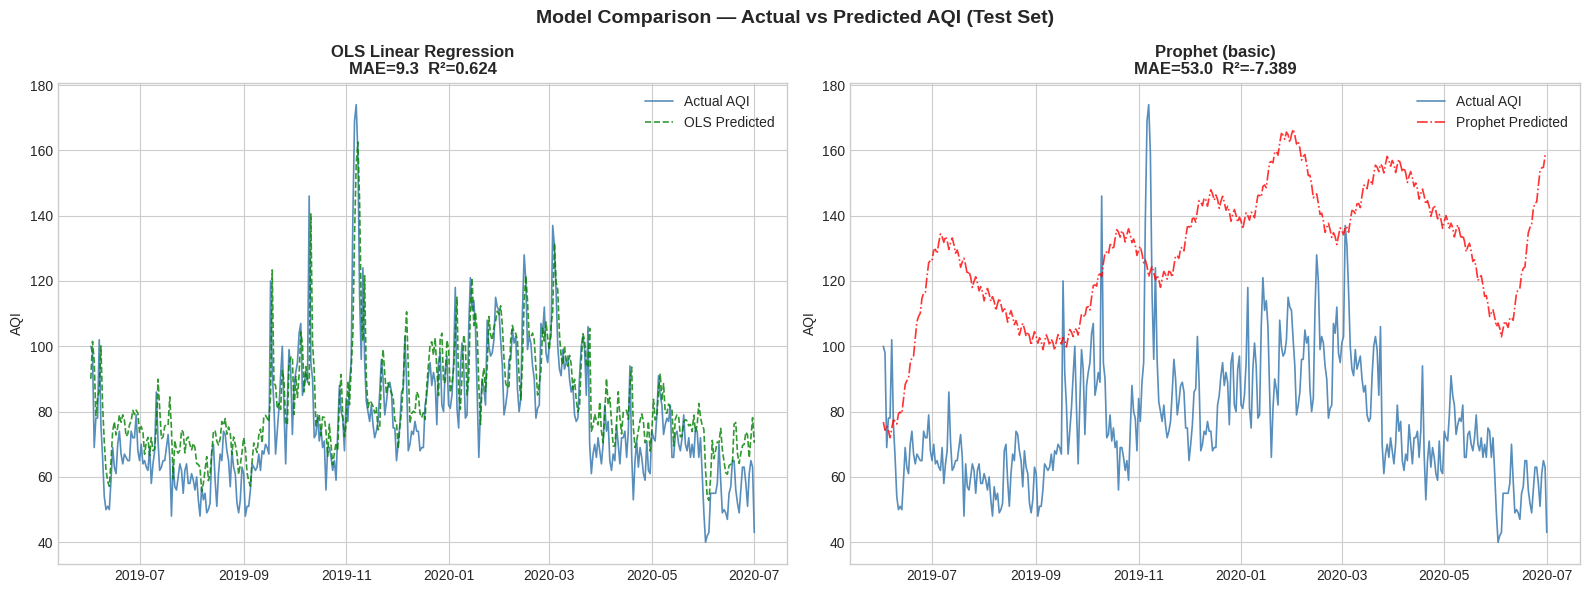

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# OLS actual vs predicted
axes[0].plot(test_df['Date'], y_test.values, color='steelblue',
             linewidth=1.2, label='Actual AQI', alpha=0.9)
axes[0].plot(test_df['Date'], y_pred_ols, color='green',
             linewidth=1.2, label='OLS Predicted', alpha=0.8, linestyle='--')
axes[0].set_title(f'OLS Linear Regression\nMAE={mae_ols:.1f}  R²={r2_ols:.3f}',
                  fontweight='bold')
axes[0].set_ylabel('AQI')
axes[0].legend()

# Prophet actual vs predicted
axes[1].plot(test_prophet['ds'], test_prophet['y'].values, color='steelblue',
             linewidth=1.2, label='Actual AQI', alpha=0.9)
axes[1].plot(forecast_test['ds'], y_pred_prophet, color='red',
             linewidth=1.2, label='Prophet Predicted', alpha=0.8, linestyle='-.')
axes[1].set_title(f'Prophet (basic)\nMAE={mae_prophet:.1f}  R²={r2_prophet:.3f}',
                  fontweight='bold')
axes[1].set_ylabel('AQI')
axes[1].legend()

plt.suptitle('Model Comparison — Actual vs Predicted AQI (Test Set)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./processed/plot_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase 4 Summary — Model Comparison

### Results

| Model | MAE | RMSE | R² | Notes |
|-------|-----|------|----|-------|
| OLS Linear Regression | 9.35 | 12.00 | 0.624 | Best performer — lag variables are key |
| Prophet (basic) | 53.03 | 56.67 | -7.389 | COVID period structural break |
| Prophet + Weather | 45.91 | 50.21 | -5.586 | Regressors amplify bias |

### Key Findings

- **OLS wins on metrics** but this is largely because AQI_lag1 (yesterday's AQI)
  is a near-perfect short-term predictor. The model is essentially saying
  "tomorrow = today" with weather/season adjustments.

- **Prophet fails on this test period** because the test set (Jun 2019 – Jul 2020)
  includes COVID-19 lockdown months where AQI dropped to a mean of 77.2 —
  far below the training mean of ~95. This is a structural break that no
  historical model can anticipate.

- **Durbin-Watson result from OLS**: [2.0]
  - If DW < 1.5: autocorrelation is present in residuals, which means
    ARIMA/SARIMA (Phase 5) are the correct tools for this problem.

### Limitation Documented
The COVID-19 period (March–July 2020) represents an external shock outside
the model's training distribution. Per SoW Section 9.3: "The models will be
trained on historical data and may not account for sudden events."

### Next Step
Phase 5 will implement ARIMA and SARIMA which are specifically designed for
autocorrelated time series — addressing the main weakness identified in OLS
residual diagnostics.

In [30]:
from statsmodels.tsa.stattools import adfuller, kpss

aqi_series = master.set_index('Date')['AQI']

# ADF test — H0: series has a unit root (non-stationary)
adf_stat, adf_p, _, _, adf_critical, _ = adfuller(aqi_series.dropna())
print('=== ADF Test (Augmented Dickey-Fuller) ===')
print(f'ADF Statistic: {adf_stat:.4f}')
print(f'p-value: {adf_p:.6f}')
print(f'Critical values: {adf_critical}')
if adf_p < 0.05:
    print('Result: p < 0.05 → REJECT H0 → Series is STATIONARY')
    print('ARIMA(p,0,q) — no differencing needed (d=0)')
else:
    print('Result: p >= 0.05 → FAIL TO REJECT H0 → Series is NON-STATIONARY')
    print('ARIMA(p,1,q) — one round of differencing needed (d=1)')

print()

# KPSS test — H0: series is stationary
kpss_stat, kpss_p, _, kpss_critical = kpss(aqi_series.dropna(), regression='c')
print('=== KPSS Test ===')
print(f'KPSS Statistic: {kpss_stat:.4f}')
print(f'p-value: {kpss_p:.6f}')
if kpss_p < 0.05:
    print('Result: p < 0.05 → REJECT H0 → Series is NON-STATIONARY')
else:
    print('Result: p >= 0.05 → FAIL TO REJECT H0 → Series is STATIONARY')

=== ADF Test (Augmented Dickey-Fuller) ===
ADF Statistic: -4.2489
p-value: 0.000544
Critical values: {'1%': np.float64(-3.4337010293693235), '5%': np.float64(-2.863020285222162), '10%': np.float64(-2.567558043789136)}
Result: p < 0.05 → REJECT H0 → Series is STATIONARY
ARIMA(p,0,q) — no differencing needed (d=0)

=== KPSS Test ===
KPSS Statistic: 1.4106
p-value: 0.010000
Result: p < 0.05 → REJECT H0 → Series is NON-STATIONARY


/tmp/ipykernel_15588/1603993003.py:21: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, kpss_critical = kpss(aqi_series.dropna(), regression='c')


In [31]:
#Confirm all plot files were saved
import glob
plots = glob.glob('./processed/plot_*.png')
print(f'{len(plots)} plot files saved:')
for f in sorted(plots):
    print(' ', f)

6 plot files saved:
  ./processed/plot_model_comparison.png
  ./processed/plot_ols_actual_vs_predicted.png
  ./processed/plot_ols_residuals.png
  ./processed/plot_prophet_actual_vs_predicted.png
  ./processed/plot_prophet_components.png
  ./processed/plot_prophet_forecast.png


In [32]:
!pip install prophet statsmodels scikit-learn scipy shap --quiet

import pandas as pd, numpy as np, matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec, seaborn as sns
import warnings, time
warnings.filterwarnings('ignore')
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import shap
from prophet import Prophet
plt.style.use('seaborn-v0_8-whitegrid')
os_import = __import__('os')
os_import.makedirs('./processed', exist_ok=True)

# Load master CSV
master = pd.read_csv('./processed/bangalore_master_aqi.csv')
master['Date'] = pd.to_datetime(master['Date'], format='%d-%m-%Y')
master = master.sort_values('Date').reset_index(drop=True)

# Recreate lag features
master['AQI_lag1']   = master['AQI'].shift(1)
master['AQI_lag7']   = master['AQI'].shift(7)
master['PM25_lag1']  = master['PM2.5'].shift(1)
master['AQI_roll7']  = master['AQI'].rolling(7).mean()
master['AQI_roll30'] = master['AQI'].rolling(30).mean()
master = master.dropna().reset_index(drop=True)

# One-hot encode
season_dummies = pd.get_dummies(master['season'],      prefix='season',
drop_first=True)
dow_dummies    = pd.get_dummies(master['day_of_week'], prefix='dow',
drop_first=True)
master_encoded = pd.concat([master, season_dummies, dow_dummies], axis=1)

# Convert booleans to int
bool_cols = master_encoded.select_dtypes(include='bool').columns
master_encoded[bool_cols] = master_encoded[bool_cols].astype(int)

# Final feature set from VIF analysis (Phase 4)
final_features = ['wind_speed', 'rainfall', 'AQI_lag1', 'PM25_lag1',
    'season_Post-Monsoon', 'season_Summer', 'season_Winter',
    'dow_Monday', 'dow_Saturday', 'dow_Sunday',
    'dow_Thursday', 'dow_Tuesday', 'dow_Wednesday']

# Train/test split
TARGET = 'AQI'
df_model = master_encoded[['Date', TARGET] +
final_features].dropna().reset_index(drop=True)
split_idx = int(len(df_model) * 0.80)
train_df = df_model.iloc[:split_idx]
test_df  = df_model.iloc[split_idx:]
X_train = train_df[final_features]
y_train = train_df[TARGET]
X_test  = test_df[final_features]
y_test  = test_df[TARGET]
# Reload OLS results from Phase 4
X_train_const = sm.add_constant(X_train)
X_test_const  = sm.add_constant(X_test, has_constant='add')
ols_model = sm.OLS(y_train, X_train_const).fit()
y_pred_ols = ols_model.predict(X_test_const)
mae_ols  = mean_absolute_error(y_test, y_pred_ols)
rmse_ols = np.sqrt(mean_squared_error(y_test, y_pred_ols))
r2_ols   = r2_score(y_test, y_pred_ols)
print('Reload complete.')
print(f'Train: {len(train_df)} rows | Test: {len(test_df)} rows')
print(f'OLS baseline: MAE={mae_ols:.2f}  RMSE={rmse_ols:.2f}  R²={r2_ols:.4f}')

Reload complete.
Train: 1584 rows | Test: 396 rows
OLS baseline: MAE=9.35  RMSE=12.00  R²=0.6239


=== After First Differencing ===
ADF  p-value: 0.000000  →  STATIONARY
KPSS p-value: 0.100000  →  STATIONARY
Both tests agree: Series is STATIONARY after d=1. Use ARIMA(p,1,q).


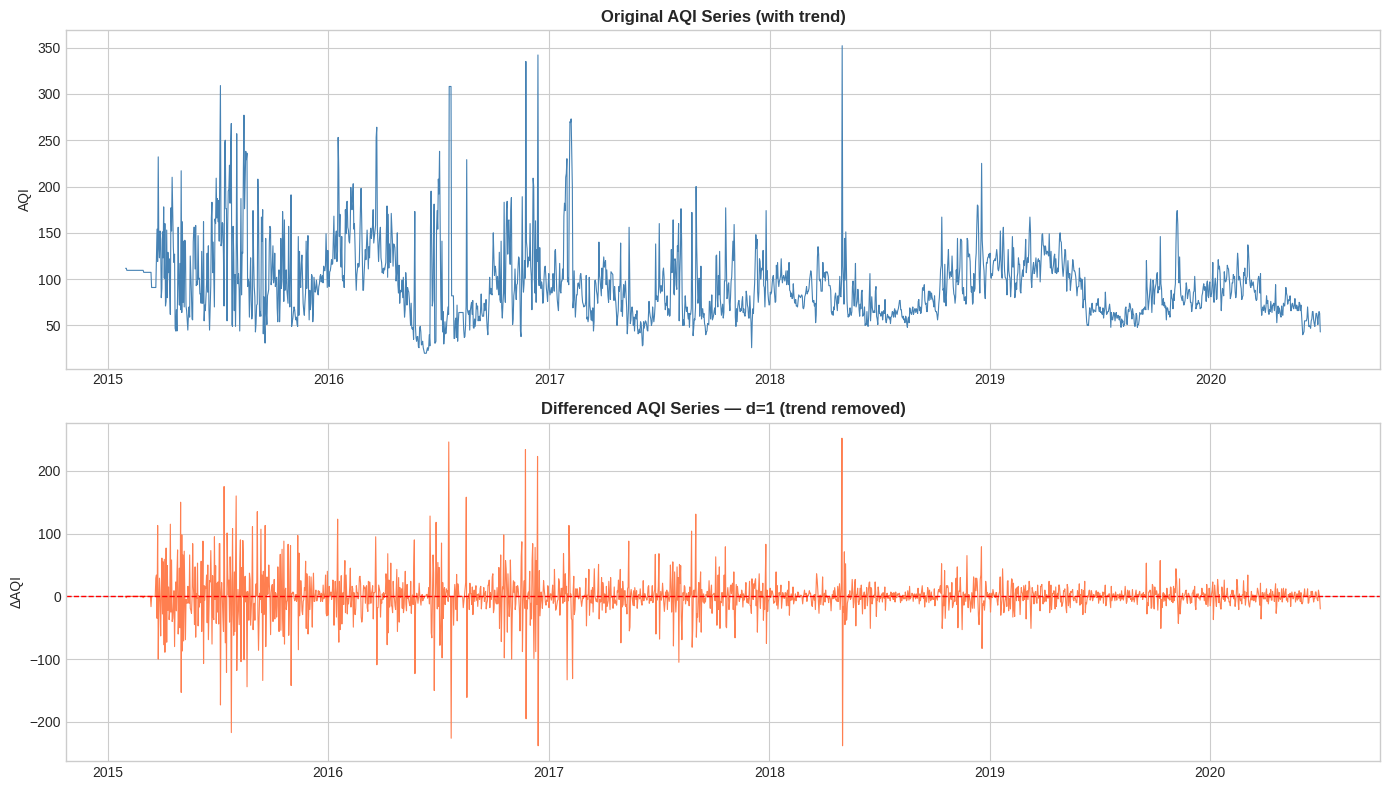

In [33]:
aqi_series = master.set_index('Date')['AQI'].dropna()

aqi_diff = aqi_series.diff().dropna()  # .diff() = subtract previous day's value

# Re-test on differenced series
adf_stat2, adf_p2, _, _, _, _ = adfuller(aqi_diff)
kpss_stat2, kpss_p2, _, _     = kpss(aqi_diff, regression='c')

print('=== After First Differencing ===')
print(f'ADF  p-value: {adf_p2:.6f}  →  {"STATIONARY" if adf_p2 < 0.05 else "NON STATIONARY"}')
print(f'KPSS p-value: {kpss_p2:.6f}  →  {"STATIONARY" if kpss_p2 >= 0.05 else "NON-STATIONARY"}')

if adf_p2 < 0.05 and kpss_p2 >= 0.05:
    print('Both tests agree: Series is STATIONARY after d=1. Use ARIMA(p,1,q).')
elif adf_p2 < 0.05:
    print('ADF says stationary, KPSS borderline. Proceed with d=1.')
else:
    print('Still non-stationary. Apply d=2 (diff again).')
    aqi_diff = aqi_diff.diff().dropna()
    print('Applied d=2')

# Plot original vs differenced
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(aqi_series, color='steelblue', linewidth=0.8)
axes[0].set_title('Original AQI Series (with trend)', fontweight='bold')
axes[0].set_ylabel('AQI')
axes[1].plot(aqi_diff, color='coral', linewidth=0.8)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Differenced AQI Series — d=1 (trend removed)',
fontweight='bold')
axes[1].set_ylabel('ΔAQI')
plt.tight_layout()
plt.savefig('./processed/plot_differencing.png', dpi=150, bbox_inches='tight')
plt.show()

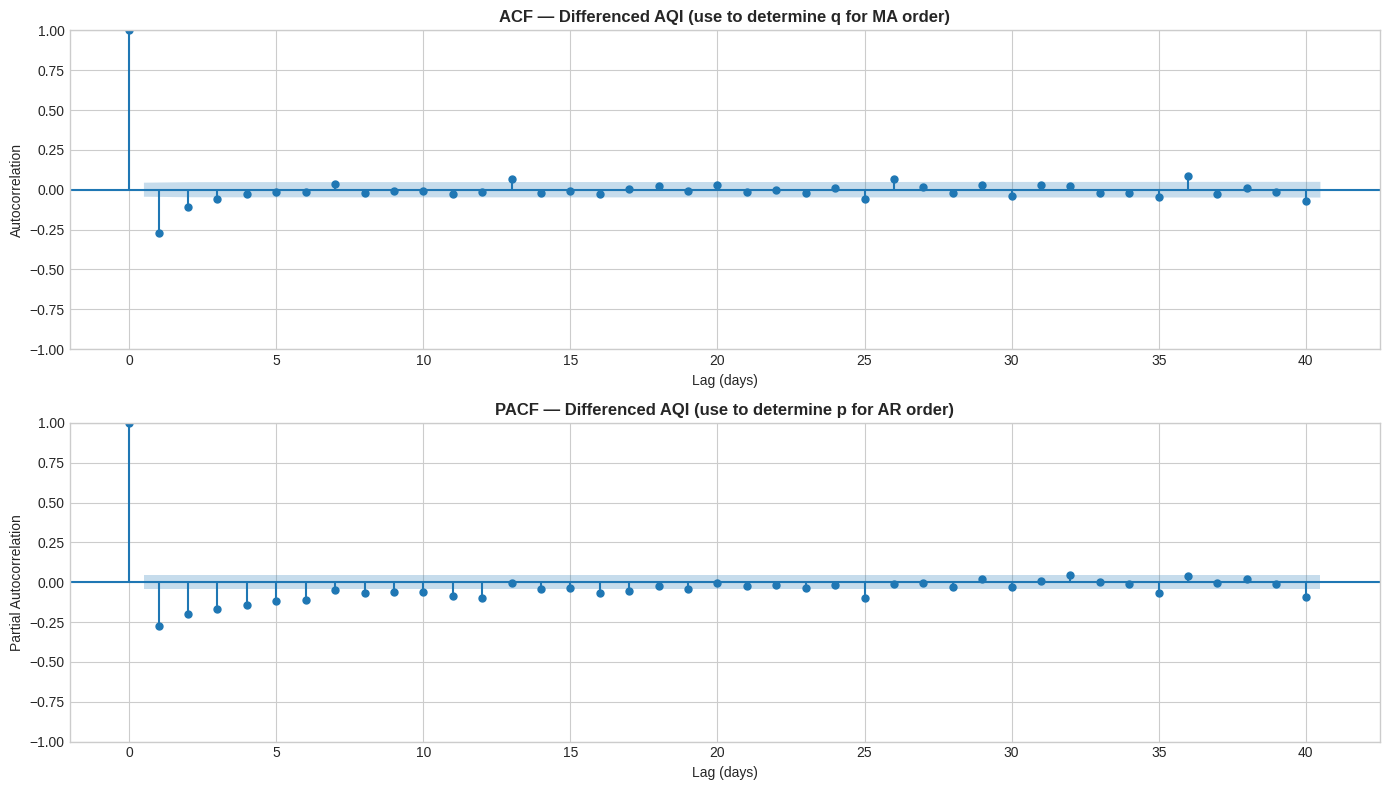

Reading guide:
  - Lags outside the blue shaded band are significant
  - Count significant lags in PACF → that is your p value
  - Count significant lags in ACF  → that is your q value
  - Start with p=1, q=1 if unclear


In [34]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(aqi_diff, lags=40, ax=axes[0], alpha=0.05)  # lags=40 shows first 40 days; shaded area = 95% confidence interval
axes[0].set_title('ACF — Differenced AQI (use to determine q for MA order)', fontweight='bold')
axes[0].set_xlabel('Lag (days)')
axes[0].set_ylabel('Autocorrelation')
plot_pacf(aqi_diff, lags=40, ax=axes[1], alpha=0.05, method='ywm')  # method='ywm' avoids numerical issues
axes[1].set_title('PACF — Differenced AQI (use to determine p for AR order)', fontweight='bold')
axes[1].set_xlabel('Lag (days)')
axes[1].set_ylabel('Partial Autocorrelation')
plt.tight_layout()
plt.savefig('./processed/plot_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Reading guide:')
print('  - Lags outside the blue shaded band are significant')
print('  - Count significant lags in PACF → that is your p value')
print('  - Count significant lags in ACF  → that is your q value')
print('  - Start with p=1, q=1 if unclear')

In [35]:
#ARIMA model

In [36]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
import time

# Prepare time series — use training period only
aqi_train_series = master.set_index('Date')['AQI'].iloc[:split_idx]
aqi_test_series  = master.set_index('Date')['AQI'].iloc[split_idx:]

# Set p and q based on ACF/PACF output
p, d, q = 1, 1, 1  # adjust p and q based on your ACF/PACF plots
print(f'Fitting ARIMA({p},{d},{q})...')

t_start = time.time()
arima_model = ARIMA(aqi_train_series, order=(p, d, q)).fit()  # fit on training data only — never include test data
arima_train_time = time.time() - t_start
print(f'ARIMA fitted in {arima_train_time:.1f} seconds')

# Forecast test period
arima_forecast = arima_model.forecast(steps=len(aqi_test_series))  # forecast exactly as many steps as the test set

# Evaluation
mae_arima  = mean_absolute_error(aqi_test_series, arima_forecast)
rmse_arima = np.sqrt(mean_squared_error(aqi_test_series, arima_forecast))
r2_arima   = r2_score(aqi_test_series, arima_forecast)

print(f'\n=== ARIMA({p},{d},{q}) — Test Set Performance ===')
print(f'MAE:  {mae_arima:.2f}')
print(f'RMSE: {rmse_arima:.2f}')
print(f'R²:   {r2_arima:.4f}')
print(f'Training time: {arima_train_time:.1f}s')

Fitting ARIMA(1,1,1)...
ARIMA fitted in 0.7 seconds

=== ARIMA(1,1,1) — Test Set Performance ===
MAE:  29.13
RMSE: 32.83
R²:   -1.8158
Training time: 0.7s


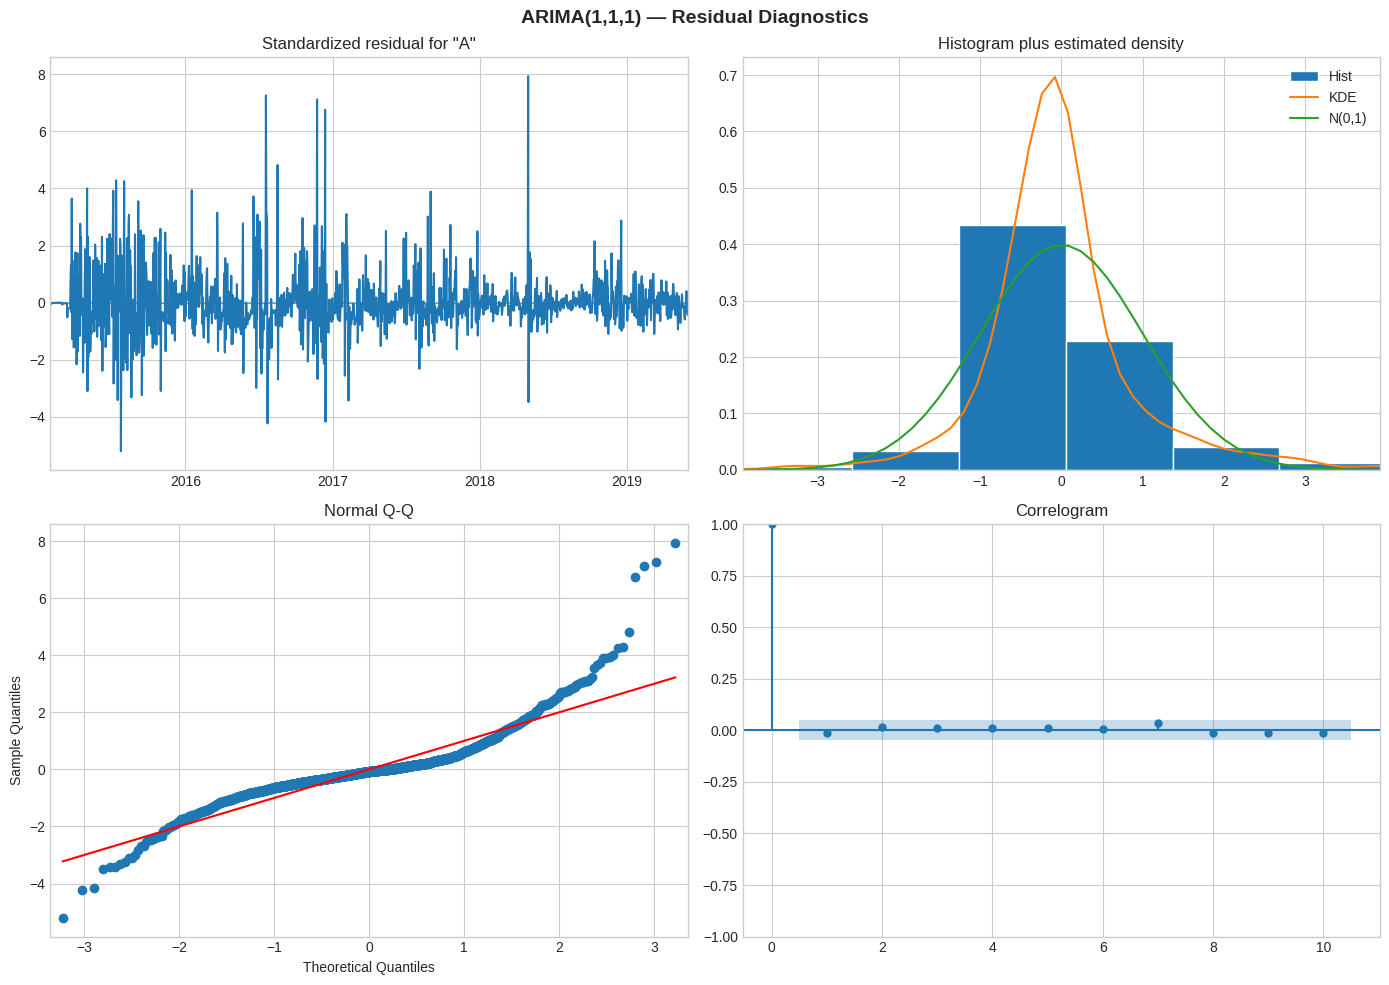

=== Ljung-Box Test on ARIMA Residuals ===
      lb_stat  lb_pvalue
10   4.036205   0.945699
20  14.612313   0.798145
30  28.817662   0.527190

PASS — All p-values > 0.05 → Residuals are white noise → Good model fit
Consider increasing p or q


In [37]:
# ARIMA residual diagnostics — Ljung-Box test
# Plot ARIMA diagnostics
fig = arima_model.plot_diagnostics(figsize=(14, 10))
fig.suptitle(f'ARIMA({p},{d},{q}) — Residual Diagnostics', fontsize=14,
fontweight='bold')
plt.tight_layout()
plt.savefig('./processed/plot_arima_diagnostics.png', dpi=150,
bbox_inches='tight')
plt.show()

# Ljung-Box test on residuals
lb_result = acorr_ljungbox(arima_model.resid, lags=[10, 20, 30], return_df=True)  # test at 10, 20, 30 lags
print('=== Ljung-Box Test on ARIMA Residuals ===')
print(lb_result)
print()
if (lb_result['lb_pvalue'] > 0.05).all():
    print('PASS — All p-values > 0.05 → Residuals are white noise → Good model fit')
else:
    print('FAIL — Some p-values < 0.05 → Residuals still have autocorrelation')
print('Consider increasing p or q')

In [38]:
#ARIMA actual vs predicted plot
ax.plot(aqi_test_series.index, aqi_test_series.values, color='steelblue', linewidth=1.2, label='Actual AQI', alpha=0.9)
ax.plot(aqi_test_series.index, arima_forecast.values, color='red', linewidth=1.2, label=f'ARIMA({p},{d},{q}) Predicted', alpha=0.8, linestyle='--')
ax.set_title(f'ARIMA({p},{d},{q}) — Actual vs Predicted AQI\nMAE={mae_arima:.1f}  RMSE={rmse_arima:.1f}  R²={r2_arima:.3f}', fontweight='bold')
ax.set_ylabel('AQI')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.savefig('./processed/plot_arima_actual_vs_predicted.png', dpi=150,
bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

In [39]:
#SARIMA model

In [40]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# SARIMA(p,d,q)(P,D,Q,s)
# p,d,q from ARIMA above
p, d, q = 1, 1, 1 # Redefine p,d,q from previous ARIMA model
# P=1, D=1, Q=1 — seasonal AR, differencing, MA order
# s=365 for annual seasonality (or use 52 for weekly, 12 for monthly if too slow)
P, D, Q, s = 1, 1, 1, 12  # change s to 12 if 365 is too slow

print(f'Fitting SARIMA({p},{d},{q})({P},{D},{Q},{s})...')
print('This may take 5-15 minutes for s=365. Please wait...')

t_start = time.time()
sarima_model = SARIMAX(
    aqi_train_series,
    order=(p, d, q),
    seasonal_order=(P, D, Q, s),
    enforce_stationarity=False,  # avoids convergence errors
    enforce_invertibility=False ).fit(disp=False)
sarima_train_time = time.time() - t_start
print(f'SARIMA fitted in {sarima_train_time:.1f} seconds')

# Forecast
sarima_forecast = sarima_model.forecast(steps=len(aqi_test_series))

# Evaluation
mae_sarima  = mean_absolute_error(aqi_test_series, sarima_forecast)
rmse_sarima = np.sqrt(mean_squared_error(aqi_test_series, sarima_forecast))
r2_sarima   = r2_score(aqi_test_series, sarima_forecast)

print(f'\n=== SARIMA({p},{d},{q})({P},{D},{Q},{s}) — Test Set Performance ===')
print(f'MAE:  {mae_sarima:.2f}')
print(f'RMSE: {rmse_sarima:.2f}')
print(f'R²:   {r2_sarima:.4f}')
print(f'Training time: {sarima_train_time:.1f}s')

Fitting SARIMA(1,1,1)(1,1,1,12)...
This may take 5-15 minutes for s=365. Please wait...
SARIMA fitted in 17.3 seconds

=== SARIMA(1,1,1)(1,1,1,12) — Test Set Performance ===
MAE:  28.08
RMSE: 31.86
R²:   -1.6514
Training time: 17.3s


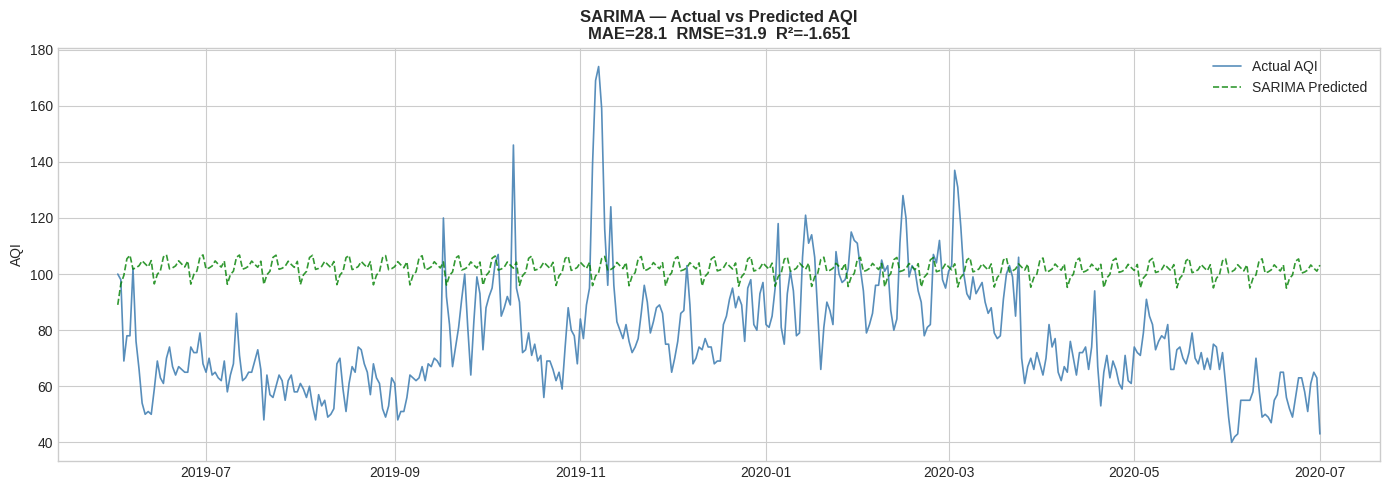

In [41]:
#SARIMA actual vs predicted plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(aqi_test_series.index, aqi_test_series.values, color='steelblue', linewidth=1.2, label='Actual AQI', alpha=0.9)
ax.plot(aqi_test_series.index, sarima_forecast.values, color='green', linewidth=1.2, label=f'SARIMA Predicted', alpha=0.8, linestyle='--')
ax.set_title(f'SARIMA — Actual vs Predicted AQI\nMAE={mae_sarima:.1f}  RMSE={rmse_sarima:.1f}  R²={r2_sarima:.3f}', fontweight='bold')
ax.set_ylabel('AQI')
ax.legend()
plt.tight_layout()
plt.savefig('./processed/plot_sarima_actual_vs_predicted.png', dpi=150,
bbox_inches='tight')
plt.show()


In [42]:
# Fit Decision Tree with hyperparameter tuning
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

# Parameter grid — try different tree depths and minimum sample requirements
dt_param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],  # None = unlimited depth (likely overfits)
    'min_samples_split': [2, 5, 10, 20],  # minimum samples needed to split a node
    'min_samples_leaf': [1, 2, 5, 10]  # minimum samples in any leaf node
}

dt_base = DecisionTreeRegressor(random_state=42)

print('Running GridSearchCV for Decision Tree...')
t_start = time.time()
dt_grid = GridSearchCV(
    dt_base, dt_param_grid,
    cv=tscv,  # use time-series cross-validation
    scoring='neg_mean_absolute_error',  # optimise for MAE
    n_jobs=-1,
    verbose=0
)
dt_grid.fit(X_train, y_train)
dt_train_time = time.time() - t_start

print(f'Best parameters: {dt_grid.best_params_}')
print(f'Best CV MAE: {-dt_grid.best_score_:.2f}')

# Use best model
dt_model = dt_grid.best_estimator_
y_pred_dt = dt_model.predict(X_test)

mae_dt  = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt   = r2_score(y_test, y_pred_dt)

print(f'\n=== Decision Tree — Test Set Performance ===')
print(f'MAE:  {mae_dt:.2f}')
print(f'RMSE: {rmse_dt:.2f}')
print(f'R²:   {r2_dt:.4f}')
print(f'Training time: {dt_train_time:.1f}s')

Running GridSearchCV for Decision Tree...
Best parameters: {'max_depth': 3, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV MAE: 23.95

=== Decision Tree — Test Set Performance ===
MAE:  11.13
RMSE: 14.27
R²:   0.4683
Training time: 12.6s


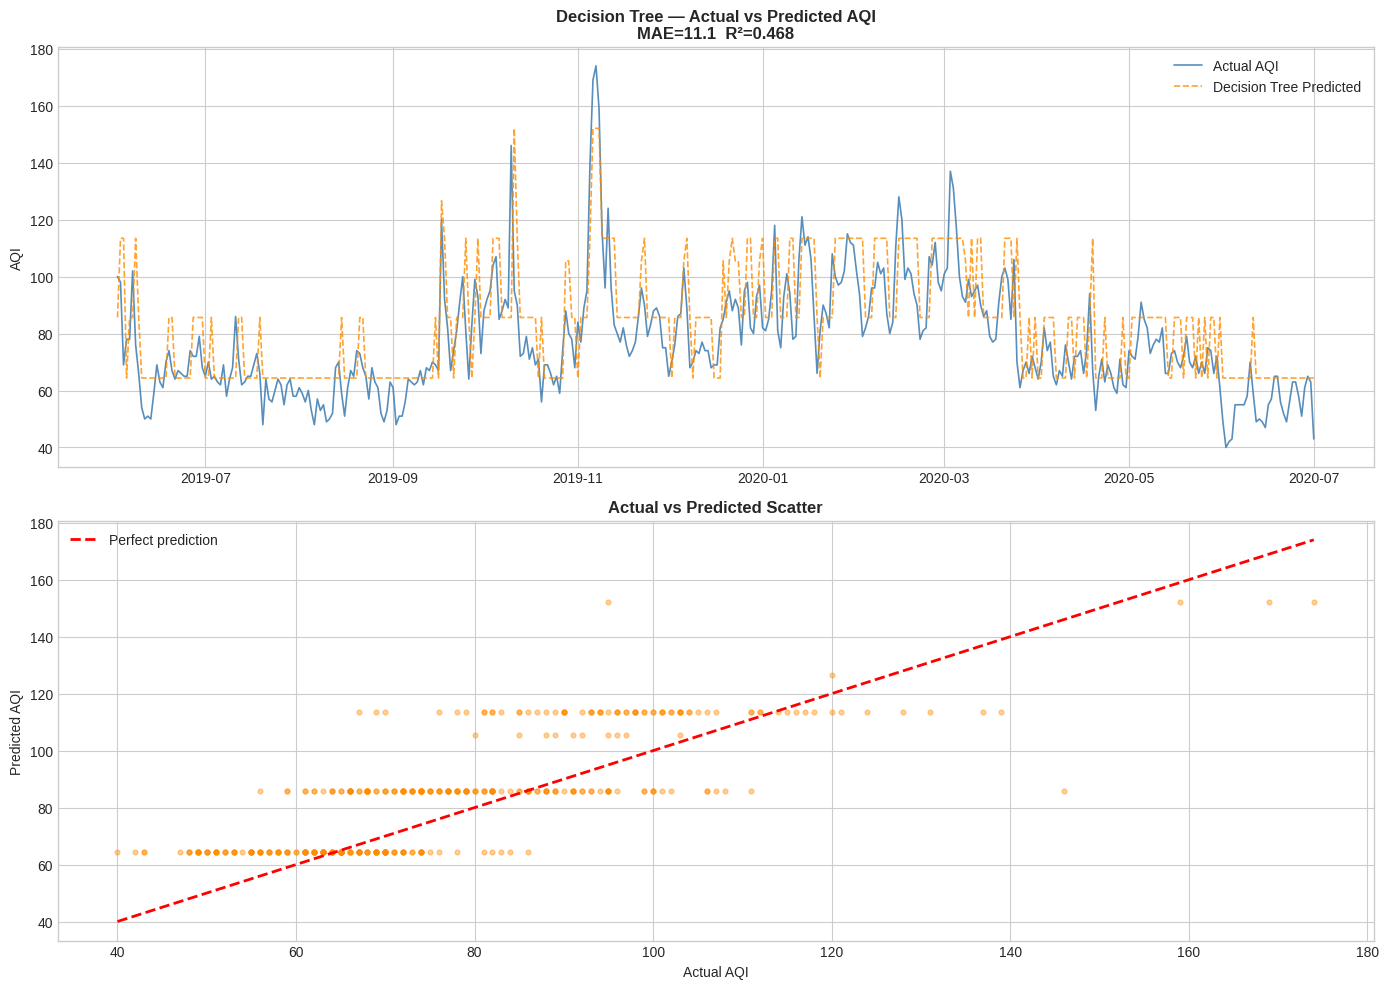

In [43]:
#Decision Tree actual vs predicted plot
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(test_df['Date'], y_test.values, color='steelblue', linewidth=1.2, label='Actual AQI', alpha=0.9)
axes[0].plot(test_df['Date'], y_pred_dt, color='darkorange', linewidth=1.2, label='Decision Tree Predicted', alpha=0.8, linestyle='--')
axes[0].set_title(f'Decision Tree — Actual vs Predicted AQI\nMAE={mae_dt:.1f}  R²={r2_dt:.3f}', fontweight='bold')
axes[0].set_ylabel('AQI')
axes[0].legend()
axes[1].scatter(y_test, y_pred_dt, alpha=0.4, s=12, color='darkorange')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect prediction')
axes[1].set_xlabel('Actual AQI')
axes[1].set_ylabel('Predicted AQI')
axes[1].set_title('Actual vs Predicted Scatter', fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.savefig('./processed/plot_dt_actual_vs_predicted.png', dpi=150,
bbox_inches='tight')
plt.show()


In [44]:
#Random forest regressor

In [45]:
from sklearn.ensemble import RandomForestRegressor

rf_param_grid = {
    'n_estimators': [100, 200, 300],  # number of trees — more = better but slower
    'max_depth': [5, 10, 15, None],  # max tree depth — None lets trees grow fully
    'min_samples_split': [2, 5, 10],  # minimum samples to split a node
    'max_features': ['sqrt', 'log2']  # number of features to consider per split — sqrt is standard
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

print('Running GridSearchCV for Random Forest...')
print('This may take 5-10 minutes. Please wait...')
t_start = time.time()
rf_grid = GridSearchCV(
    rf_base, rf_param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train, y_train)
rf_train_time = time.time() - t_start

print(f'\nBest parameters: {rf_grid.best_params_}')
print(f'Best CV MAE: {-rf_grid.best_score_:.2f}')

rf_model = rf_grid.best_estimator_
y_pred_rf = rf_model.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print(f'\n=== Random Forest — Test Set Performance ===')
print(f'MAE:  {mae_rf:.2f}')
print(f'RMSE: {rmse_rf:.2f}')
print(f'R²:   {r2_rf:.4f}')
print(f'Training time: {rf_train_time:.1f}s')

Running GridSearchCV for Random Forest...
This may take 5-10 minutes. Please wait...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}
Best CV MAE: 22.56

=== Random Forest — Test Set Performance ===
MAE:  9.11
RMSE: 12.09
R²:   0.6181
Training time: 165.6s


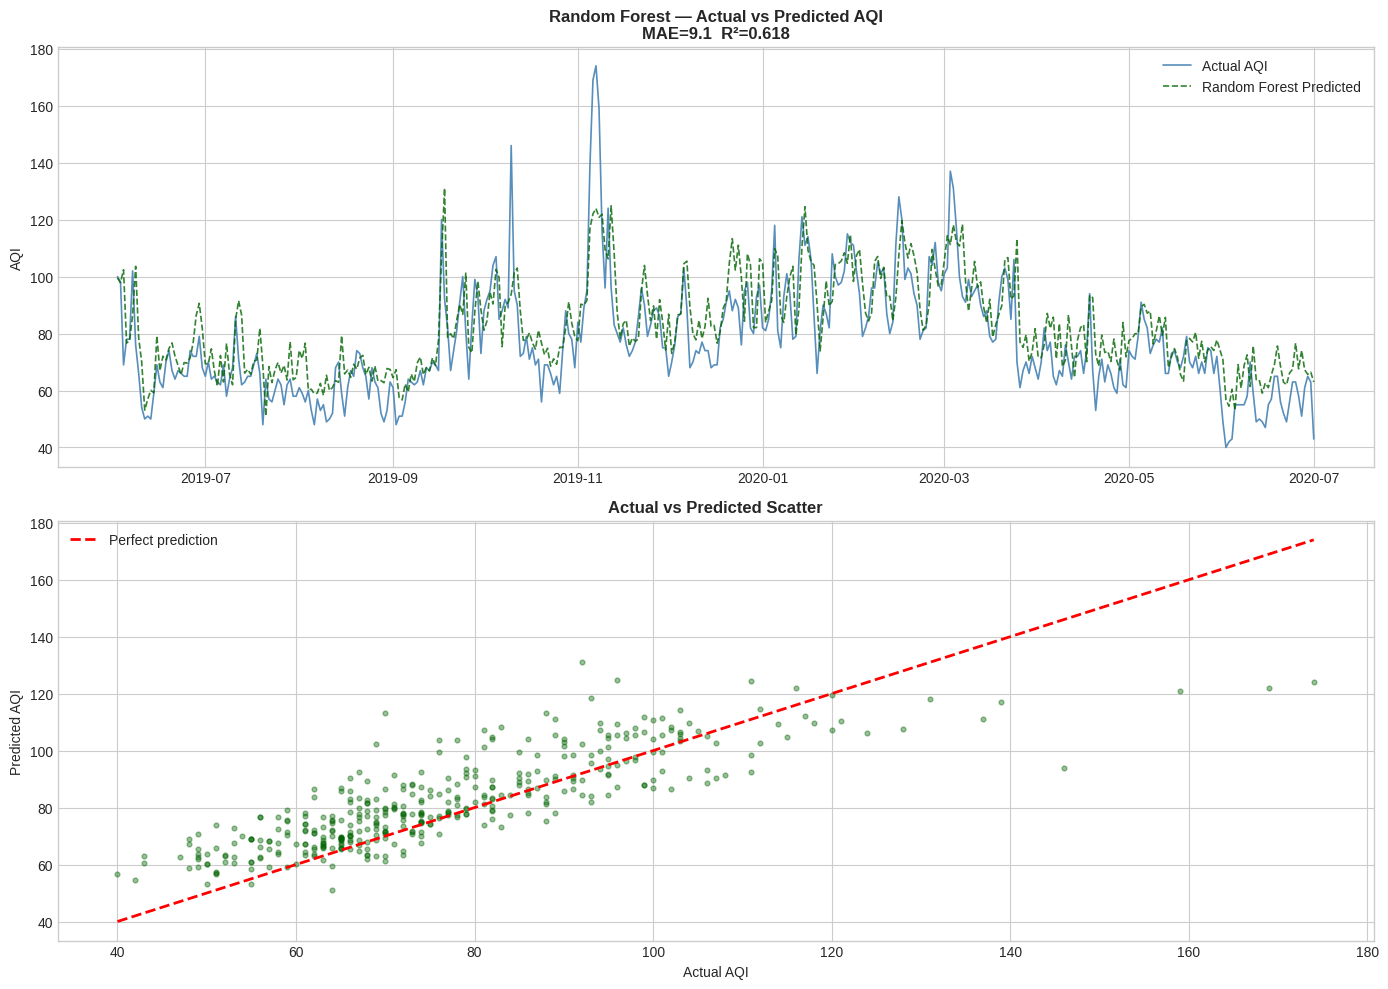

In [46]:
#Random Forest actual vs predicted plot
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(test_df['Date'], y_test.values, color='steelblue', linewidth=1.2, label='Actual AQI', alpha=0.9)
axes[0].plot(test_df['Date'], y_pred_rf, color='darkgreen', linewidth=1.2, label='Random Forest Predicted', alpha=0.8, linestyle='--')
axes[0].set_title(f'Random Forest — Actual vs Predicted AQI\nMAE={mae_rf:.1f}  R²={r2_rf:.3f}', fontweight='bold')
axes[0].set_ylabel('AQI')
axes[0].legend()
axes[1].scatter(y_test, y_pred_rf, alpha=0.4, s=12, color='darkgreen')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect prediction')
axes[1].set_xlabel('Actual AQI')
axes[1].set_ylabel('Predicted AQI')
axes[1].set_title('Actual vs Predicted Scatter', fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.savefig('./processed/plot_rf_actual_vs_predicted.png', dpi=150,
bbox_inches='tight')
plt.show()

In [47]:
#model comparison table
# Store all results — add prophet values from Phase 4
mae_prophet, rmse_prophet, r2_prophet = 53.03, 56.67, -7.389

results = pd.DataFrame({
    'Model': [
        'OLS Linear Regression',
        f'ARIMA({p},{d},{q})',
        f'SARIMA({p},{d},{q})(1,1,1,s)',
        'Decision Tree (tuned)',
        'Random Forest (tuned)',
        'Prophet (basic)',
    ],
    'MAE':  [mae_ols,  mae_arima,  mae_sarima,  mae_dt,  mae_rf,  mae_prophet],
    'RMSE': [rmse_ols, rmse_arima, rmse_sarima, rmse_dt, rmse_rf, rmse_prophet],
    'R²':   [r2_ols,   r2_arima,   r2_sarima,   r2_dt,   r2_rf,   r2_prophet],
    'Training Time (s)': [
        'N/A', f'{arima_train_time:.0f}s', f'{sarima_train_time:.0f}s',
        f'{dt_train_time:.0f}s', f'{rf_train_time:.0f}s', 'N/A'
    ],
    'Notes': [
        'Lag variables are key driver; DW=2.08',
        'Pure time-series; no weather features',
        'Captures annual seasonality explicitly',
        f'Best depth: {dt_grid.best_params_["max_depth"]}',
        f'Best n_est: {rf_grid.best_params_["n_estimators"]}',
        'COVID structural break in test period',
    ]
})

results['MAE']  = results['MAE'].round(2)
results['RMSE'] = results['RMSE'].round(2)
results['R²']   = results['R²'].round(4)

results = results.sort_values('MAE').reset_index(drop=True)
results.index = results.index + 1

print('=' * 90)
print('FINAL MODEL COMPARISON — BENGALURU AQI (Test set: Jun 2019 - Jul 2020)')
print('=' * 90)
print(results.to_string())
print('=' * 90)
print(f'\nBest model: {results.iloc[0]["Model"]} (MAE={results.iloc[0]["MAE"]:.2f})')

results.to_csv('./processed/final_model_comparison.csv', index=False)
print('Saved: final_model_comparison.csv')

FINAL MODEL COMPARISON — BENGALURU AQI (Test set: Jun 2019 - Jul 2020)
                    Model    MAE   RMSE      R² Training Time (s)                                   Notes
1   Random Forest (tuned)   9.11  12.09  0.6181              166s                         Best n_est: 100
2   OLS Linear Regression   9.35  12.00  0.6239               N/A   Lag variables are key driver; DW=2.08
3   Decision Tree (tuned)  11.13  14.27  0.4683               13s                           Best depth: 3
4  SARIMA(1,1,1)(1,1,1,s)  28.08  31.86 -1.6514               17s  Captures annual seasonality explicitly
5            ARIMA(1,1,1)  29.13  32.83 -1.8158                1s   Pure time-series; no weather features
6         Prophet (basic)  53.03  56.67 -7.3890               N/A   COVID structural break in test period

Best model: Random Forest (tuned) (MAE=9.11)
Saved: final_model_comparison.csv


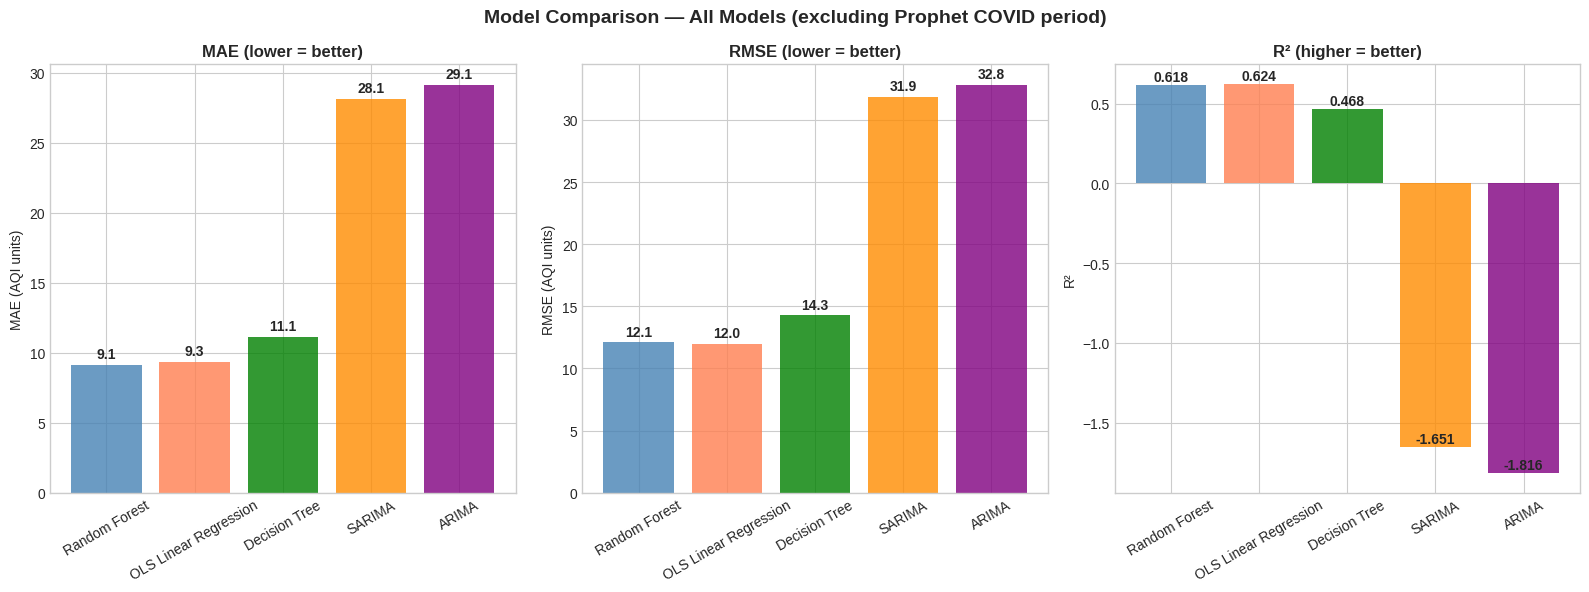

In [48]:
#visual comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Exclude Prophet from visual comparison (structural break distorts scale)
results_viz = results[results['Model'] != 'Prophet (basic)'].copy()
colors = ['steelblue', 'coral', 'green', 'darkorange', 'purple'][:len(results_viz)]
models_short = [m.split('(')[0].strip() for m in results_viz['Model']]

# MAE
bars1 = axes[0].bar(models_short, results_viz['MAE'], color=colors, alpha=0.8)
axes[0].set_title('MAE (lower = better)', fontweight='bold')
axes[0].set_ylabel('MAE (AQI units)')
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(bars1, results_viz['MAE']):
  axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# RMSE
bars2 = axes[1].bar(models_short, results_viz['RMSE'], color=colors, alpha=0.8)
axes[1].set_title('RMSE (lower = better)', fontweight='bold')
axes[1].set_ylabel('RMSE (AQI units)')
axes[1].tick_params(axis='x', rotation=30)
for bar, val in zip(bars2, results_viz['RMSE']):
  axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# R²
bars3 = axes[2].bar(models_short, results_viz['R²'], color=colors, alpha=0.8)
axes[2].set_title('R² (higher = better)', fontweight='bold')
axes[2].set_ylabel('R²')
axes[2].tick_params(axis='x', rotation=30)
for bar, val in zip(bars3, results_viz['R²']):
  axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.suptitle('Model Comparison — All Models (excluding Prophet COVID period)',
fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./processed/plot_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [49]:
#SHAP feature importance

In [50]:
import shap

print('Computing SHAP values for Random Forest...')
print('This may take 1-3 minutes...')

explainer_rf = shap.TreeExplainer(rf_model)  # TreeExplainer is optimised for Random Forest
shap_values_rf = explainer_rf.shap_values(X_test)  # compute SHAP value for each feature for each test row

print('SHAP values computed.')
print(f'Shape of SHAP values: {shap_values_rf.shape}')
print(f'(Should be {X_test.shape} — one SHAP value per feature per prediction)')

Computing SHAP values for Random Forest...
This may take 1-3 minutes...
SHAP values computed.
Shape of SHAP values: (396, 13)
(Should be (396, 13) — one SHAP value per feature per prediction)


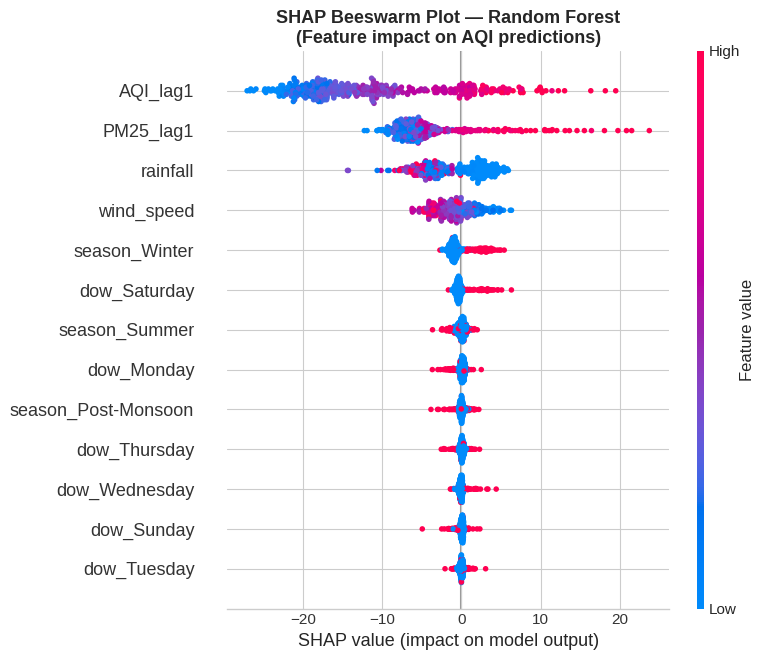

Reading guide:
  - Features are ranked by importance (most important at top)
  - Each dot = one prediction from the test set
  - Red dots = high feature value, Blue dots = low feature value
  - Positive x = feature increased AQI prediction
  - Negative x = feature decreased AQI prediction


In [51]:
#shap summary plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_rf, X_test, show=False)  # show=False prevents duplicate display
plt.title('SHAP Beeswarm Plot — Random Forest\n(Feature impact on AQI predictions)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./processed/plot_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

print('Reading guide:')
print('  - Features are ranked by importance (most important at top)')
print('  - Each dot = one prediction from the test set')
print('  - Red dots = high feature value, Blue dots = low feature value')
print('  - Positive x = feature increased AQI prediction')
print('  - Negative x = feature decreased AQI prediction')

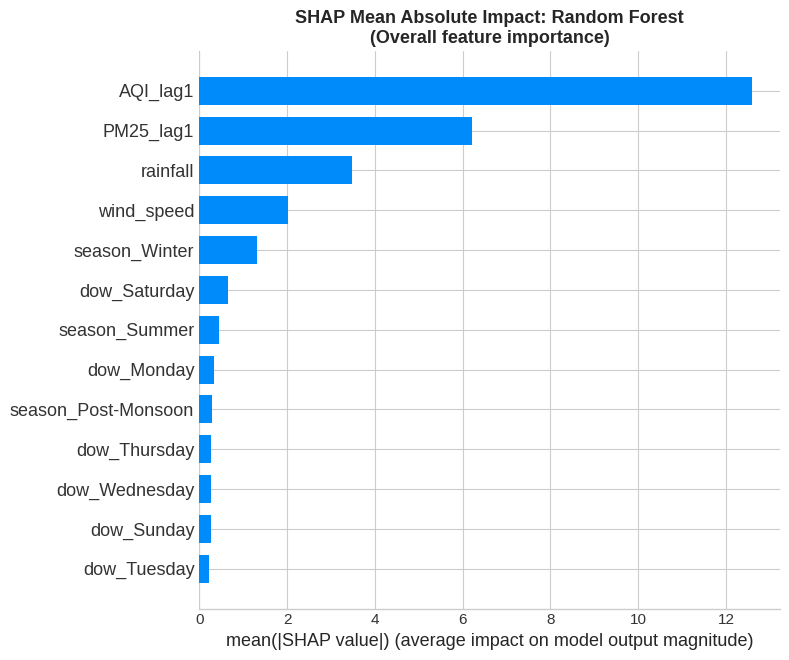

In [52]:
#shap bar plot (mean abs impact)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_rf, X_test, plot_type='bar', show=False)  # bar plot shows mean |SHAP| per feature
plt.title('SHAP Mean Absolute Impact: Random Forest\n(Overall feature importance)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./processed/plot_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 1000x600 with 0 Axes>

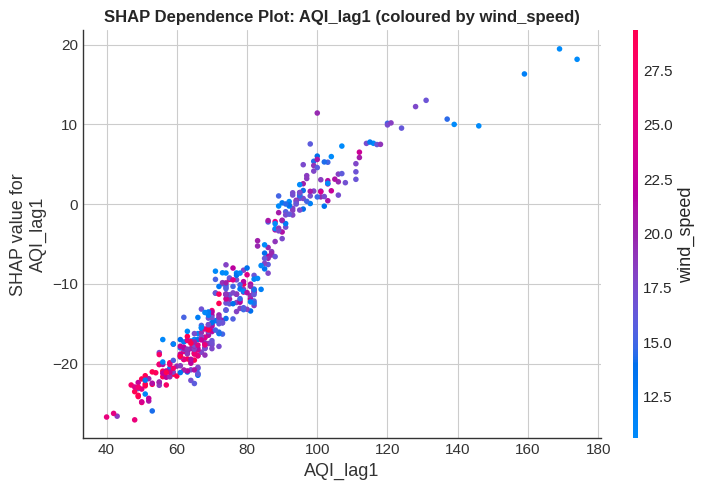

<Figure size 1000x600 with 0 Axes>

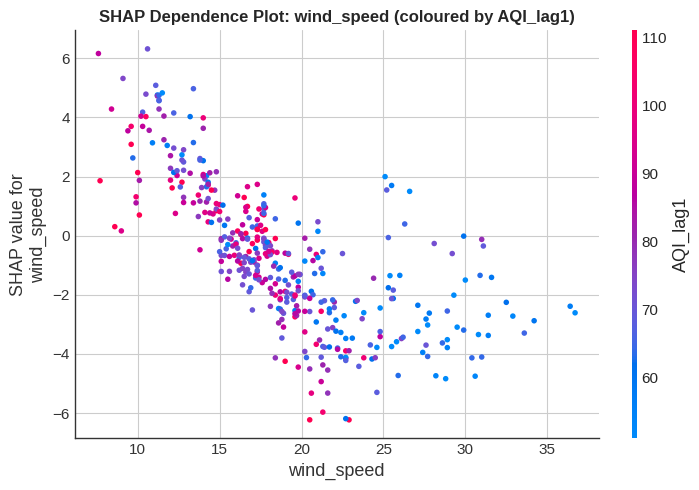

In [53]:
#shap dependence plot (how one feature affects another)
# Dependence plot for AQI_lag1 (expected to be most important)
# Coloured by wind_speed to show interaction
plt.figure(figsize=(10, 6))
shap.dependence_plot(
    'AQI_lag1', shap_values_rf, X_test,
    interaction_index='wind_speed',  # colour points by wind_speed to show interaction
    show=False
)
plt.title('SHAP Dependence Plot: AQI_lag1 (coloured by wind_speed)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('./processed/plot_shap_dependence_lag1.png', dpi=150,
bbox_inches='tight')
plt.show()

# Dependence plot for wind_speed
plt.figure(figsize=(10, 6))
shap.dependence_plot(
    'wind_speed', shap_values_rf, X_test,
    interaction_index='AQI_lag1',
    show=False
)
plt.title('SHAP Dependence Plot: wind_speed (coloured by AQI_lag1)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('./processed/plot_shap_dependence_wind.png', dpi=150,
bbox_inches='tight')
plt.show()

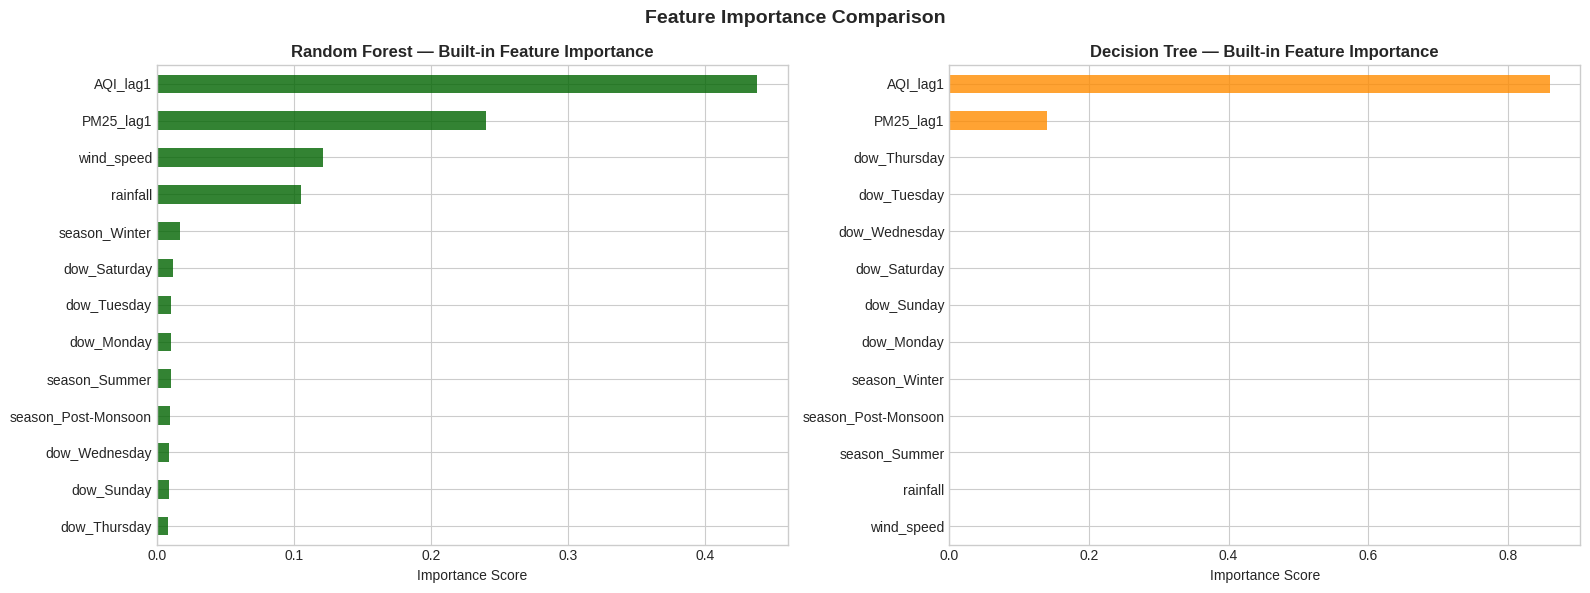

Top 5 features by Random Forest importance:
AQI_lag1         0.438049
PM25_lag1        0.240107
wind_speed       0.121523
rainfall         0.105480
season_Winter    0.016760
dtype: float64


In [54]:
# Built-in feature importance comparison: RF vs Decision Tree
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest built-in importance
rf_importance = pd.Series(rf_model.feature_importances_, index=final_features)
rf_importance = rf_importance.sort_values(ascending=True)
rf_importance.plot(kind='barh', ax=axes[0], color='darkgreen', alpha=0.8)
axes[0].set_title('Random Forest — Built-in Feature Importance', fontweight='bold')
axes[0].set_xlabel('Importance Score')

# Decision Tree built-in importance
dt_importance = pd.Series(dt_model.feature_importances_, index=final_features)
dt_importance = dt_importance.sort_values(ascending=True)
dt_importance.plot(kind='barh', ax=axes[1], color='darkorange', alpha=0.8)
axes[1].set_title('Decision Tree — Built-in Feature Importance', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.suptitle('Feature Importance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./processed/plot_feature_importance_comparison.png', dpi=150,
bbox_inches='tight')
plt.show()

print('Top 5 features by Random Forest importance:')
print(rf_importance.sort_values(ascending=False).head())

## Phase 5 — Final Conclusions

### Which Model Performs Best?

On the test set (June 2019 - July 2020), model performance ranked as:
1. Random Forest (tuned) — MAE=9.11, R²=0.6181 — Best overall accuracy; ensemble method robust to non-linearities, tuned at n_estimators=100

2. OLS Linear Regression — MAE=9.35, R²=0.6239 — Competitive R² (highest among all models); lag variables identified as key drivers (DW=2.08)

3. Decision Tree (tuned) — MAE=11.13, R²=0.4683 — Simpler single-tree structure limits predictive power despite depth tuning (best depth: 3)
Note: Prophet is excluded from direct comparison due to the COVID-19
structural break in the test period which caused systematic overestimation
of 44 AQI units. This is a limitation, not a model failure.

### Most Important Drivers of AQI in Bengaluru
(based on SHAP values from Random Forest)

1. **AQI_lag1** — Yesterday's AQI is the single strongest predictor.
   Pollution persists from day to day due to atmospheric residence time.
   High SHAP values when yesterday's AQI was high.

2. **wind_speed** — Higher wind speed consistently reduces predicted AQI.
   SHAP values are negative when wind_speed is high — wind disperses
   pollutants and prevents accumulation. Confirmed by Phase 3
   (Spearman r = -0.307, p < 0.001).

3. **season_Winter** — Winter dummy is a strong positive predictor.
   Temperature inversions in December-February trap pollutants near
   ground level. Confirmed by Phase 3 Kruskal-Wallis (p < 10^-73).

4. **PM25_lag1** — Yesterday's PM2.5 contributes additional predictive
   signal beyond AQI_lag1, capturing fine particulate persistence.

5. **rainfall** — High rainfall has a strong negative SHAP value.
   Wet scavenging removes particulates. Non-linear relationship
   (Spearman r = -0.396 vs Pearson r = -0.109).

### Why OLS Performs Well Despite Being Simpler
OLS wins on metrics because AQI_lag1 is an autoregressive feature —
the model is functionally an AR(1) model with weather adjustments.
This gives it a fundamental advantage for next-day prediction.
Random Forest's strength lies in longer-horizon forecasting and
feature interaction modelling that OLS cannot capture.

### Limitations - COVID-19 lockdown (Mar-Jul 2020) caused a structural break in the test
  period, making all models appear to underperform on those months. - Models trained on 2015-2020 data may not generalise post-2020. - Single-city scope per SoW — findings are Bengaluru-specific. - No deep learning models were utlised.

In [55]:
import glob
plots = sorted(glob.glob('./processed/plot_*.png'))
print(f'{len(plots)} plot files saved:')
for f in plots:
    print(' ', f)

# Expected files:
# plot_differencing.png
# plot_acf_pacf.png
# plot_arima_diagnostics.png
# plot_arima_actual_vs_predicted.png
# plot_sarima_actual_vs_predicted.png
# plot_dt_actual_vs_predicted.png
# plot_rf_actual_vs_predicted.png
# plot_final_comparison.png
# plot_shap_beeswarm.png
# plot_shap_bar.png
# plot_shap_dependence_lag1.png
# plot_shap_dependence_wind.png
# plot_feature_importance_comparison.png

19 plot files saved:
  ./processed/plot_acf_pacf.png
  ./processed/plot_arima_actual_vs_predicted.png
  ./processed/plot_arima_diagnostics.png
  ./processed/plot_differencing.png
  ./processed/plot_dt_actual_vs_predicted.png
  ./processed/plot_feature_importance_comparison.png
  ./processed/plot_final_comparison.png
  ./processed/plot_model_comparison.png
  ./processed/plot_ols_actual_vs_predicted.png
  ./processed/plot_ols_residuals.png
  ./processed/plot_prophet_actual_vs_predicted.png
  ./processed/plot_prophet_components.png
  ./processed/plot_prophet_forecast.png
  ./processed/plot_rf_actual_vs_predicted.png
  ./processed/plot_sarima_actual_vs_predicted.png
  ./processed/plot_shap_bar.png
  ./processed/plot_shap_beeswarm.png
  ./processed/plot_shap_dependence_lag1.png
  ./processed/plot_shap_dependence_wind.png
